# EDA of NYC Yellow Taxi Datasets

This project was designed to analyze NYC Yellow Taxi data from the months of January, March, and May in the year 2020 to determine the best features for predicting trip time. The data was analyzed for data drift due to the influence of the COVID-19 pandemic on taxi rides during this time period. This notebook covers the exploratory data analysis (EDA) performed on these datasets, using Tensorflow Data Validation (TFDV) to explore data drift and traditional Python data libraries (NumPy, Pandas, Matplotlib, and Seaborn) to explore feature relations and interactions.

# Load Data and Feature Extraction

In [1]:
# Load libaries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import tensorflow_data_validation as tfdv

# Custom functions for manipulating Pandas dataframes and for data cleaning
from modules.preprocessing import (
    normalize_column_names,
    feature_extraction,
    map_via_data_dictionary,
    impute_missing_values,
    remove_domain_outliers,
    impute_and_remove_manual_outliers,
    drop_unneeded_columns,
    convert_to_categorical,
    feature_select_and_encode_eda
)

# Custom functions for statistical calculations
from modules.statistics import (
    calculate_data_proportion,
    display_quantiles,
    fisher_z_test_correlations,
    calculate_multi_VIF
)

# Custom function for setting drift comparators for Tensorflow Data Validation
from modules.tfdv_utils import set_drift_comparators

# Custom functions for plotting
from modules.plotting import (
    # Correlations, associations, and Kruskal-Wallis
    correlation_heatmap,
    association_heatmap,
    plot_correlation_differences,
    plot_association_differences,
    plot_kruskal_wallis_heatmap,

    # Custom plots using seaborn
    custom_countplot,
    custom_histplot,
    custom_boxplot,
    custom_regplot,
    custom_hexbin,

    # Meta functions for combining plots
    overlay_plots,
    hue_plots
)

2026-05-04 13:59:18.574445: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-04 13:59:18.587595: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-04 13:59:18.591280: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-04 13:59:18.601741: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 13:59:19.653213: W tensorflow/compiler/tf2

In [2]:
# Load datasets
jan_data = pd.read_parquet('../data/yellow_tripdata_2020-01.parquet')
march_data = pd.read_parquet('../data/yellow_tripdata_2020-03.parquet')
may_data = pd.read_parquet('../data/yellow_tripdata_2020-05.parquet')

In [3]:
# Normalize column names to snake case
jan_data = normalize_column_names(jan_data)
march_data = normalize_column_names(march_data)
may_data = normalize_column_names(may_data)

In [4]:
# Check data types and column names
march_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3007687 entries, 0 to 3007686
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   vendor_id              int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   ratecode_id            float64       
 6   store_and_fwd_flag     object        
 7   pu_location_id         int64         
 8   do_location_id         int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

We need to extract some features from the datetime variables in the dataset. Our goal is to improve ride time predictions, so we need trip time. Average speed can be used to check for outlier data by comparing to speed limits, and pick up hour can be used for future analysis to check if the time the ride occurred was important.

- Trip Time (in hours as a float): `(data.tpep_dropoff_datetime - data.tpep_pickup_datetime) / np.timedelta64(1, 'h')`
- Average Speed (in miles per hour):  `data.trip_distance / data.trip_time`
- Pick Up Hour: `data.tpep_pickup_datetime.dt.hour`

In [5]:
# Extract trip time, average speed, and pickup hour features and remove now redundant date-time features
jan_data = feature_extraction(jan_data)
march_data = feature_extraction(march_data)
may_data = feature_extraction(may_data)

In [6]:
# Recheck column types and column names
march_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3007687 entries, 0 to 3007686
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   vendor_id              int64  
 1   pickup_hour            int64  
 2   trip_time              float64
 3   passenger_count        float64
 4   trip_distance          float64
 5   avg_speed              float64
 6   ratecode_id            float64
 7   store_and_fwd_flag     object 
 8   pu_location_id         int64  
 9   do_location_id         int64  
 10  payment_type           int64  
 11  fare_amount            float64
 12  extra                  float64
 13  mta_tax                float64
 14  tip_amount             float64
 15  tolls_amount           float64
 16  improvement_surcharge  float64
 17  total_amount           float64
 18  congestion_surcharge   float64
 19  airport_fee            object 
dtypes: float64(13), int64(5), object(2)
memory usage: 458.9+ MB


# Converting Columns Using the Data Dictionary

Using the data dictionary from the nyc.gov website, the following variables will be converted to categorical columns instead of numeric ones.

- vendor_id:  `1: 'Creative Mobile Technologies, LLC', 2: 'Curb Mobility, LLC', 6: 'Myle Technologies Inc'`
- ratecode_id: `1: 'Standard', 2: 'JFK', 3: 'Newark', 4: 'Nassau/Westchester', 5: 'Negotiated', 6: 'Group', 99: np.nan`
- payment_type: `0: 'Flex', 1: 'Credit', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: np.nan, 6: 'Voided'`

Data Dictionary: https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf

In [7]:
# Convert vendor ID, rate code ID, and payment type to categorical variables
jan_data = map_via_data_dictionary(jan_data)
march_data = map_via_data_dictionary(march_data)
may_data = map_via_data_dictionary(may_data)

# Dealing with Outliers and Missing Data

## Missing Data

In [8]:
# Null counts for all columns
march_data.isnull().sum()

vendor_id                      9
pickup_hour                    0
trip_time                      0
passenger_count            37808
trip_distance                  0
avg_speed                   1881
ratecode_id                37928
store_and_fwd_flag         37808
pu_location_id                 0
do_location_id                 0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge       37808
airport_fee              3007687
dtype: int64

Although there are only 9 records with missing vendor IDs, and we could drop the data since it is so insignifcant, it would be better to impute with the most common vendor ID: Curb Mobility, LLC. It is reasonable that since over 65% of data is done using the most common vendor that these data points are also using the same vendor.

In [9]:
# Most common vendor is Curb Mobility, LLC
march_data.vendor_id.value_counts(normalize = True)

Curb Mobility, LLC                   0.671188
Creative Mobile Technologies, LLC    0.328654
Myle Technologies Inc                0.000158
Name: vendor_id, dtype: float64

For imputing the passenger count, mode imputation once again seems reasonable. Over 73% of trips involve 1 passenger, so it is not a stretch to imagine that these missing values likely include 1 passenger as well.

It should be noted that taxicabs always have at least one passenger, and so the zeros present in the data will need to be changed. The maximum number of allowable passengers in a taxicab is 5, with exceptions made for younger passengers held in lap. Passenger counts higher than 5 will be capped at 5.

- Passenger FAQ: https://www.nyc.gov/site/tlc/passengers/passenger-frequently-asked-questions.page

In [10]:
# Most common number of passengers is 1
march_data.passenger_count.value_counts(normalize = True)

1.0    0.736532
2.0    0.137216
3.0    0.035866
5.0    0.032653
0.0    0.021358
6.0    0.020059
4.0    0.016308
7.0    0.000003
9.0    0.000003
8.0    0.000002
Name: passenger_count, dtype: float64

Rate Codes Rules:

- Yellow Taxi Data Dictionary: https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf
- Taxi Fare Information: https://www.nyc.gov/site/tlc/passengers/taxi-fare.page
- Taxi Information for Yellow Cabs PDF: https://www.nyc.gov/assets/tlc/downloads/pdf/taxi_information.pdf

Rate code is tricky to figure out how to impute. There are 6 main rate codes:
- 1: Standard Rate
- 2: Ends in JFK (Zone 132)
- 3: Ends in Newark (Zone 1)
- 4: Ends in Nassau or Westchester, outside of New York (Zone 265)
- 5: Ends in Dutchess, Orange, Putnam, Rockland, or Suffolk, outside of New York (Zone 265)
- 6: Group Ride with 2, 3, or 4 people in certain areas of NY

It is simple to impute rate codes 2 and 3 by simply checking if the ride ends in the proper zone. Imputing rate codes 4 and 5 is tricky since we do not have actual location information and they are all encoded as Zone 265. Rate code 6 can be imputed using the congestion surcharge (see below), as group rides have a congestion surcharge of \\$0.75 compared to the usual congestion surcharge of \\$2.50.

We will impute missing rate codes as follows:
- JFK if `do_location_id == 132`
- Newark if `do_location_id == 1`
- Negotiated (rate code 5) if `pu_location_id == 265` or `do_location_id == 265`, as this is the most common rate code for entries with those location ids.
- Group Ride (rate code 6) if `congestion_surcharge == 0.75`
- Standard for everything else

In [11]:
# Most common out of NYC rate code is rate code 5 = Negotiated
march_data[(march_data.pu_location_id == 265) | (march_data.do_location_id == 265)].ratecode_id.value_counts()

Negotiated            2704
Nassau/Westchester    1899
Standard              1782
Newark                 403
JFK                     51
Group                    1
Name: ratecode_id, dtype: int64

For store and forward flags, 99% of the data uses the flag "N". It thus makes sense to impute missing values as "N", as this appears to be the most common method for storing trip data. Frankly, this column seems like it might not have any value for modeling or EDA, given how imbalanced it is. Logically, it only indicates whether the vehicle help the trip record in memory versus immediately sending the trip record to the server, which should have no influence on trip time. This column will be dropped.

In [12]:
# Most common flag is N
march_data.store_and_fwd_flag.value_counts(normalize = True)

N    0.990578
Y    0.009422
Name: store_and_fwd_flag, dtype: float64

Congestion Surcharge

- Department of Taxation and Finance, Congestion Surcharge: https://www.tax.ny.gov/bus/cs/csidx.htm

Note that the congestion surchage should be either \\$0, \\$0.75, or \\$2.50. It would appear that a surcharge of \\$2.50 is applied throughout most of the city, so it is reasonable to assume that the standard \\$2.50 congestion surcharge is applied, except when the rate code ID is Group, in which case the congestion surcharge of \\$0.75 should be used instead.

The negative values will be assumed to be positive values, and the value of \\$1.00 will be treated as missing.

In [13]:
# Most common congestion surcharge is $2.50
march_data.congestion_surcharge.value_counts()

 2.50    2703215
 0.00     258050
-2.50       8587
 0.75         25
-0.75          1
 1.00          1
Name: congestion_surcharge, dtype: int64

Note that airport fees are missing for the entire dataset, so the column should be dropped.

In [14]:
# Airport fees are completely missing for all datasets
march_data.airport_fee.value_counts()

Series([], Name: airport_fee, dtype: int64)

In [15]:
# Airport fees are completely missing for all datasets
jan_data.airport_fee.value_counts()

Series([], Name: airport_fee, dtype: int64)

In [16]:
# Airport fees are completely missing for all datasets
may_data.airport_fee.value_counts()

Series([], Name: airport_fee, dtype: int64)

For places where the average speed is null, the trip time is 0. This means that these values are the result of a divide by 0 error. Records where the trip time is zero do not make any sense, as they effectively were not rides if the passenger entered the vehicle and then immediately left, so these records should be removed as bad data.

In [17]:
# Records with missing average speed are the result of divide by 0 errors with 0 trip time
march_data[march_data.avg_speed.isnull()].trip_time.value_counts()

0.0    1881
Name: trip_time, dtype: int64

Normally when imputing missing values, the best theoretical method is to compute relevant statistics on the training dataset and use those calculated statistics for imputing values on the validation and testing datasets.

While this is a best practice for modeling using a single static dataset split into training, validation, and testing datasets, this is only true under the assumption that this data all comes from the exact same distribution. When splitting up a single dataset, this is a reasonable assumption.

In production, datasets from different time periods should be grouped together, as distribution shift is highly likely, and those shifts will be difficult to detect if using imputed statistics from a prior distribution. Thus, each dataset is given the same imputation treatment conditioned on its own innate statistics where applicable.

Steps:
- Fill in vendor ID with mode
- Enforce congestion surcharge to \\$0, \\$0.75, or \\$2.50, imputing missing values to \\$0.75 if `ratecode_id == 'Group'` or to \\$2.50 otherwise
- Clip passenger counts between 1 and 5, and impute missing values as 1 passenger (which is also the mode)
- Impute rate code as JFK if `do_location_id == 132`, as Newark if `do_location_id == 1`, as the most common out of state code (which happens to be Negotiated) if `do_location_id | pu_location_id == 265`, as Group if `congestion_surcharge == 0.75`, and finally as Standard otherwise

In [18]:
# Imputing missing values
jan_data = impute_missing_values(jan_data)
march_data = impute_missing_values(march_data)
may_data = impute_missing_values(may_data)

## Identifying Outliers

### Domain Knowledge Pruning

The speed limit among the various boroughs tops out at 50 miles per hour, according to the official NYC speed limit maps. To be generous, any trips with an average speed greater than 70 miles per hour will be removed as outliers, as it is assumed that taxicabs are roughly following the speed limit. Trips with lower average speed than 0 effectively do not move and should be removed as well for representing bad data.

- NYC Speed Limit Maps: https://www.nyc.gov/html/dot/downloads/pdf/current-pre-vision-zero-speed-limit-maps.pdf

In [19]:
# About 1% of the data contains bad trip speed values
calculate_data_proportion(march_data, slice_argument = (march_data.avg_speed <= 0) | (march_data.avg_speed >= 70))

0.010797001150718143

According to the NYC TLC Rules and Local Laws, Chapter 63-11 (d), taxi cab drivers may not operate for more than 12 hours every 24 hours. Therefore, any trips over 12 hours should be dropped as bad data, and any trips with 0 or negative trip time should be dropped.

- NYC TLC Rules and Local Laws: https://www.nyc.gov/assets/tlc/downloads/pdf/rule_book_current_chapter_63.pdf

In [20]:
# About 0.2% of the data contains bad trip time values
calculate_data_proportion(march_data, slice_argument = (march_data.trip_time > 12) | (march_data.trip_time <= 0))

0.002500592648104673

Although vehicles could theoretically move 0 miles, such as when stuck in traffic, it is highly unlikely that real taxicab trips have a trip distance of 0. Trips with 0 or negative trip distance should be dropped.

In [21]:
# About 1% of the data contains bad trip distance values
calculate_data_proportion(march_data, slice_argument = march_data.trip_distance <= 0)

0.010438586195970524

Domain knowledge outliers removed:

- Average speed in `(0, 70]`
- Trip time in `(0, 12]`
- Trip distance greater than `0`

In [22]:
# Remove the domain outliers
jan_data = remove_domain_outliers(jan_data)
march_data = remove_domain_outliers(march_data)
may_data = remove_domain_outliers(may_data)

### Manually Checking for Outlier Values

#### Outliers for Categorical Variables

Vendor ID contains proper values.

In [23]:
# View unique vendor ids
march_data.vendor_id.unique()

array(['Creative Mobile Technologies, LLC', 'Curb Mobility, LLC',
       'Myle Technologies Inc'], dtype=object)

Pickup hours are correct, ranging from 0 to 23.

In [24]:
# View unique pickup hours
np.sort(march_data.pickup_hour.unique())

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

Passenger counts are correct, ranging from 1 to 5.

In [25]:
# View unique passenger counts
np.sort(march_data.passenger_count.unique())

array([1, 2, 3, 4, 5])

Based on the official Taxi Zone lookup table, there should be 265 taxi zones.

- Taxi Zone Lookup CSV: https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv

There appear to be some missing taxi zones, but no values that are outside of the correct range (1 - 265).

In [26]:
print(f'Minimum pickup taxi zone id: {march_data.pu_location_id.min()}')
print(f'Maximum pickup taxi zone id: {march_data.pu_location_id.max()}')
print(f'Number of pickup taxi zones: {len(march_data.pu_location_id.unique())}')
print(f'Minimum drop off taxi zone id: {march_data.do_location_id.min()}')
print(f'Maximum drop off taxi zone id: {march_data.do_location_id.max()}')
print(f'Number of drop off taxi zones: {len(march_data.do_location_id.unique())}')

Minimum pickup taxi zone id: 1
Maximum pickup taxi zone id: 265
Number of pickup taxi zones: 259
Minimum drop off taxi zone id: 1
Maximum drop off taxi zone id: 265
Number of drop off taxi zones: 261


Note that Zone 264 corresponds to "Unknown", but there is no feasible way to impute this value, and so it is being left as its own category. Zone 265 correponds to outside of NYC. Together, these two zones make up a tiny portion of the total data, but they are not the rarest Zones present in the dataset, so they will be preserved as their own categories.

In [27]:
# About 0.8% of the data contains Zones 264 and 265
calculate_data_proportion(march_data, (march_data.pu_location_id > 263) | (march_data.do_location_id > 263))

0.008408420954744596

Rate code IDs contain proper values after imputation.

In [28]:
# View unique rate code IDs
march_data.ratecode_id.unique()

array(['Standard', 'JFK', 'Nassau/Westchester', 'Negotiated', 'Newark',
       'Group'], dtype=object)

Payment types contain proper values.

In [29]:
# View unique payment types
march_data.payment_type.unique()

array(['Credit', 'Cash', 'Dispute', 'No Charge', 'Flex'], dtype=object)

Note that, according to the official rates, the MTA tax should only be 0 or 50 cents. It is reasonable to assume the negative values should be positive, and that the rest of the values are bad entries. The bad entries only comprise 14 total entries in the March dataset, so they will be imputed as if the 50 cent MTA tax is used.

Official Fare Rates: https://www.nyc.gov/site/tlc/passengers/taxi-fare.page

In [30]:
# Unique MTA tax values
march_data.mta_tax.unique()

array([ 0.5 , -0.5 ,  0.  ,  3.3 ,  0.35,  0.59])

In [31]:
# Number of records with bad MTA tax values
march_data[~march_data.mta_tax.isin([0.5, 0, -0.5])].shape[0]

14

The improvement surcharge should always be 30 cents during 2020, meaning any 0 entries are incorrectly reported. Because this would make the column univalent across all of our datasets, the improvement surcharge column will be dropped. Note that this column would be important if the data spanned pre-2022 to post-2022, as the improvement surcharge was raised to 1 dollar in December 2022.

- TLC Surcharge changes December 2022: https://rules.cityofnewyork.us/rule/taximeter-rate-of-fare-and-various-surcharges/

In [32]:
# Unique improvement surcharge values
march_data.improvement_surcharge.unique()

array([ 0.3, -0.3,  0. ])

The congestion surcharge contains valid values. Note that congestion surcharge should probably not be 0 for most vehicles; however, there are some exceptions as listed in the congestion surcharge information page. Since it is impossible to tell if these data points meet those exception criteria, the 0 values will be maintained. However, for entries with a congestion surcharge of 0.75, they should use the "Group" rate code, so these records will be fixed.

In [33]:
# Unique congestion surcharge values
march_data.congestion_surcharge.unique()

array([2.5 , 0.  , 0.75])

In [34]:
# Realistically, very few records should have a congestion charge of 0
# There are too many in the data to realistically impute
# Group rate codes should have a congestion surcharge of 0.75
march_data[march_data.congestion_surcharge == 0].ratecode_id.value_counts()

Standard              216339
JFK                     6392
Newark                  5473
Negotiated              3741
Nassau/Westchester      1687
Group                      3
Name: ratecode_id, dtype: int64

In [35]:
# Most of the ratecode IDs with 0.75 surcharge are Standard, which is incorrect
march_data[march_data.congestion_surcharge == 0.75].ratecode_id.value_counts()

Standard    24
Group        2
Name: ratecode_id, dtype: int64

In [36]:
# No Group ratecode ID with 2.50 surcharge, which is correct
march_data[march_data.congestion_surcharge == 2.5].ratecode_id.value_counts()

Standard              2681531
JFK                     49551
Negotiated               2705
Nassau/Westchester        474
Newark                     55
Name: ratecode_id, dtype: int64

#### Outliers for Numeric Columns

Even after clipping the max trip time to 12 hours, there are still some trip times with abnormally long times. 99.99% of the data has trip times less than 6 hours, with only 0.01% of the data having trip times greater than 6 hours. Especially considering that the average speed during these trips seems to be almost universally less than 5 miles per hour, these records do not seem realistic. Who is in an 11.8 hour taxi ride with an average speed of 0.2 miles per hour?

These values are likely garbage data and will be dropped, losing only 296 records out of 2.96 million records for the March dataset.

In [37]:
# Descriptive statistics for trip time - no negative values but suspiciously high max value
march_data.trip_time.describe()

count    2.967977e+06
mean     2.198274e-01
std      1.939699e-01
min      2.777778e-04
25%      1.055556e-01
50%      1.738889e-01
75%      2.794444e-01
max      1.198750e+01
Name: trip_time, dtype: float64

In [38]:
display_quantiles(march_data, column = 'trip_time', quantiles = 0.9999)

99.99 percentile of trip_time: 5.969702666664186
Max of trip_time: 11.9875


In [39]:
# Entries with trip time greater than 6 hours
march_data[march_data.trip_time > 6]

,vendor_id,pickup_hour,trip_time,passenger_count,trip_distance,avg_speed,ratecode_id,store_and_fwd_flag,pu_location_id,do_location_id,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
15870,"Curb Mobility, LLC",23,7.217778,3,2.81,0.389317,Standard,N,74,167,Cash,11.50,0.50,0.5,0.00,0.0,0.3,12.80,0.0,None
38544,"Curb Mobility, LLC",6,9.558611,1,16.61,1.737700,Standard,N,70,100,Cash,55.00,0.80,0.5,0.00,0.0,0.0,56.30,0.0,None
71939,"Curb Mobility, LLC",12,11.849167,1,2.48,0.209297,Standard,N,161,113,Credit,11.50,0.00,0.5,2.22,0.0,0.3,17.02,2.5,None
75277,"Curb Mobility, LLC",13,11.000000,1,12.39,1.126364,Standard,N,132,64,Cash,35.00,0.00,0.5,0.00,0.0,0.3,35.80,0.0,None
77169,"Curb Mobility, LLC",12,11.756389,1,3.03,0.257732,Standard,N,79,163,Credit,10.50,0.00,0.5,3.45,0.0,0.3,17.25,2.5,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2956301,"Curb Mobility, LLC",13,10.843611,1,3.31,0.305249,Standard,N,48,238,Cash,12.00,0.00,0.5,0.00,0.0,0.3,15.30,2.5,None
2965681,"Curb Mobility, LLC",13,10.010278,2,4.24,0.423565,Standard,N,148,100,Cash,14.50,0.00,0.5,0.00,0.0,0.3,17.80,2.5,None
2966112,"Curb Mobility, LLC",14,9.084722,1,11.04,1.215227,Standard,N,41,255,Cash,38.50,0.00,0.5,0.00,0.0,0.3,41.80,2.5,None
2988989,Myle Technologies Inc,0,7.995000,1,2.58,0.322702,Negotiated,None,265,62,Flex,10.69,0.94,0.5,0.00,0.0,0.3,12.43,2.5,None


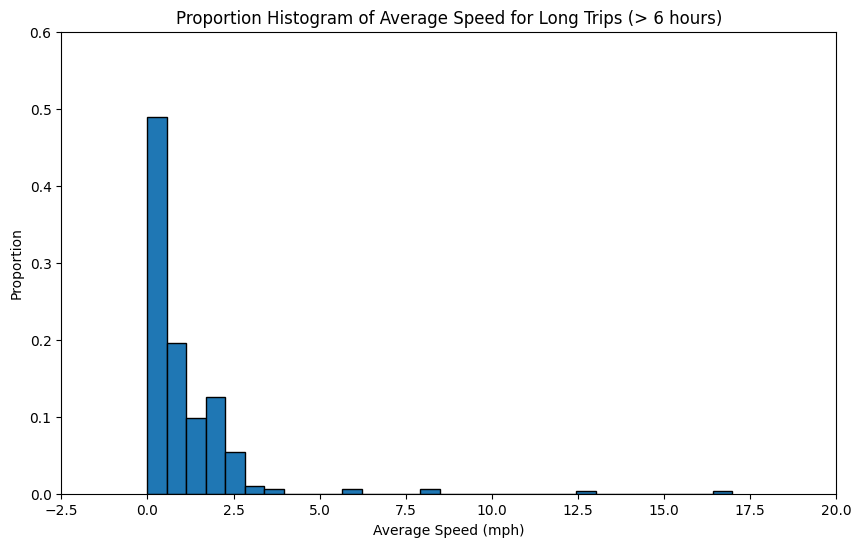

In [40]:
# Distribution of average speed for suspiciously long trips
ax = custom_histplot(march_data[march_data.trip_time > 6],
                     x = 'avg_speed', title = 'Proportion Histogram of Average Speed for Long Trips (> 6 hours)');
ax.set_xlabel('Average Speed (mph)');

The max distance for a trip (310.9 miles) is suspiciously higher than the 99.99 percentile (43.8 miles). Upon further inspection, most of these high distance "outlier" trips involve going outside of NYC (drop off Zone 265), which would naturally be longer distance trips. If the trip contains Zone 265 in the pick up or drop off location, it seems likely that these long-distance trips are not actual outliers and will be left in the data, otherwise, they will be dropped.

However, the minimum trip distance is a different story. A single street block in NYC is about 0.05 miles. It is fairly reasonable to assume that any "real" trip goes at least 5 blocks (0.25) miles, because otherwise a passenger would just walk that distance. This would be a short taxi trip, but it at least it is somewhat realistic. For this reason, trip distance will be capped on the lower end by 0.25

In [41]:
# Descriptive statistics for trip distance - no negative values but suspiciously high max value
march_data.trip_distance.describe()

count    2.967977e+06
mean     2.912197e+00
std      3.688431e+00
min      1.000000e-02
25%      1.000000e+00
50%      1.690000e+00
75%      3.060000e+00
max      3.109000e+02
Name: trip_distance, dtype: float64

In [42]:
display_quantiles(march_data, column = 'trip_distance', quantiles = 0.9999)

99.99 percentile of trip_distance: 43.82202399999834
Max of trip_distance: 310.9


In [43]:
# Most of the upper outlier trips are using rate codes for going outside of the city
march_data[march_data.trip_distance > 44].ratecode_id.value_counts()

Negotiated            124
Nassau/Westchester     81
Standard               65
Newark                 19
JFK                     2
Name: ratecode_id, dtype: int64

In [44]:
# Almost all of these upper outliers have a 265 drop off location Zone ID
# Most longer trips are going outside of the city, so these are not really outliers
march_data[march_data.trip_distance > 44].do_location_id.value_counts()

265    226
186      7
1        7
164      3
100      2
125      2
40       2
39       2
138      2
264      2
4        2
132      2
91       2
131      1
230      1
48       1
155      1
219      1
79       1
107      1
145      1
260      1
121      1
135      1
232      1
198      1
137      1
33       1
44       1
180      1
35       1
90       1
170      1
236      1
226      1
17       1
228      1
143      1
69       1
246      1
65       1
101      1
161      1
Name: do_location_id, dtype: int64

In [45]:
# Lower 1 percentile of trip distance is about 0.29 miles
march_data.trip_distance.quantile(0.01)

0.29

There are negative fare amounts which should be removed. In addition, the top level fare amounts are ludicrously high. 99.99996% of the data contains fares less than \\$770, and the max fare value is \\$671,100, which is 871x higher. While taxi fares in the high hundreds is unusual, they are not impossible, but fares in the thousands seem highly unrealistic. Records with fare greater than \\$1,000 will be removed from the dataset.

In [46]:
# Descriptive statistics for fare amount - there are negtive fare amounts and the max is very suspiciously high
march_data.fare_amount.describe()

count    2.967977e+06
mean     1.254001e+01
std      3.896899e+02
min     -3.575000e+02
25%      6.500000e+00
50%      9.000000e+00
75%      1.400000e+01
max      6.711001e+05
Name: fare_amount, dtype: float64

In [47]:
display_quantiles(march_data, column = 'fare_amount', quantiles = [0.9999996, 0.9999997])

99.99996 percentile of fare_amount: 768.8082048054785
99.99997 percentile of fare_amount: 74273.28316889043
Max of fare_amount: 671100.14


The extra amounts include all of the miscellaneous surcharges added to the trip. Thus, the extra amount should not be negative, and those records with negative entries should be removed. The max value (\\$30.3) is much higher than the 75th percentile (\\$2.50), but it is still within a reasonable scale.

In [48]:
# Descriptive statistics for extra - negative values spotted with very high extra values
march_data.extra.describe()

count    2.967977e+06
mean     1.088326e+00
std      1.244416e+00
min     -4.500000e+00
25%      0.000000e+00
50%      5.000000e-01
75%      2.500000e+00
max      3.030000e+01
Name: extra, dtype: float64

In [49]:
# Although the max is $30 which is high, it is not so unusual as to be impossible
march_data.extra.max()

30.3

As with all amounts, the tolls amount should not be negative. The current toll amount effective as of 2023 spans about \\$2.50 - \\$7.00 with E-Z Pass, which presumably all licensed taxis have. Although these are 2023 values, it is reasonable to assume that toll values were only cheaper in 2020. Thus, it should be unrealistic for toll amounts to get above about \\$50.

This is corroborated by the fact that 99.999 percent of the data has tolls amounts below \\$50.55 compared to the maximum amount of \\$601.02. Any data above \\$50.00 will be considered an outlier and removed from the dataset.

- 2023 NYC Toll Rates: https://www.mta.info/fares-tolls/tolls/vehicle-types

In [50]:
# Descriptive statistics for extra - negative values spotted with very high extra values
march_data.tolls_amount.describe()

count    2.967977e+06
mean     2.997351e-01
std      1.589611e+00
min     -4.000000e+01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.010200e+02
Name: tolls_amount, dtype: float64

In [51]:
display_quantiles(march_data, column = 'tolls_amount', quantiles = 0.99999)

99.999 percentile of tolls_amount: 50.551931200362745
Max of tolls_amount: 601.02


Cash tips are self-reported, and so most of the cash tips go unreported as a \\$0 tip. This is not something that can be cleaned from the data since it is purposefully missing due to lack of self-reporting. 99.999% of the data includes tips below \\$111.0, while the max tip amount is \\$800, almost 8x that value. This tip amount is not realistic and almost assuredly a reporting error.

Trying to determine an appropriate cap for tip amount is difficult, as realistically, tips are unlikely to exceed a certain percentage of the total fare amount. However, people are more likely to tip higher percentages of their fare when their fare is cheaper; giving \\$5 on a \\$20 fare is reasonable, while giving \\$250 on a \\$1,000 fare is much less likely. Rather than try to compute some regression value, the percentage of passengers tipping more than 10% for fares up to \\$1,000 was calculated. As expected, the tip percentage goes down as the fare rate goes up.

For this reason, a cap of \\$120 for the tip seems well within reason, 12% of the decided cap of \\$1,000 for the fare amount. This assumes the existence of some highly generous tippers but should keep most of the data.

In [52]:
# Descriptive statistics for tip amount - negative values spotted and suspiciously high max
march_data.tip_amount.describe()

count    2.967977e+06
mean     2.131494e+00
std      2.633148e+00
min     -4.932200e+02
25%      0.000000e+00
50%      1.950000e+00
75%      2.860000e+00
max      8.000000e+02
Name: tip_amount, dtype: float64

In [53]:
display_quantiles(march_data, column = 'tip_amount', quantiles = 0.99999)

99.999 percentile of tip_amount: 110.0
Max of tip_amount: 800.0


In [54]:
# Calculating low tippers (>= 10%) for different fare amounts
for fare_amount in [20, 50, 200, 300, 500, 1000]:
    num_high_tippers = march_data[
        (march_data.tip_amount >= 0.10 * march_data.fare_amount) & (march_data.fare_amount > fare_amount)
    ].shape[0]
    print(f'Number of passengers tipping 10% or more on fares of {fare_amount} or more: {num_high_tippers}')

Number of passengers tipping 10% or more on fares of 20 or more: 227683
Number of passengers tipping 10% or more on fares of 50 or more: 49713
Number of passengers tipping 10% or more on fares of 200 or more: 69
Number of passengers tipping 10% or more on fares of 300 or more: 9
Number of passengers tipping 10% or more on fares of 500 or more: 1
Number of passengers tipping 10% or more on fares of 1000 or more: 0


In [55]:
# High number of records with 0 reported tips, likely because cash tips are self-reported
march_data.tip_amount.value_counts()

0.00     844851
1.00     177984
2.00     115862
2.06      42211
1.50      42128
          ...  
32.85         1
34.20         1
22.82         1
24.41         1
13.39         1
Name: tip_amount, Length: 2905, dtype: int64

The manually inspected outliers that will be removed are:

- MTA tax is enforced to be \\$0 or \\$0.50 and imputed as \\$0.50$ if otherwise invalid, since the MTA tax is enforced for nearly all trips.
- ``congestion_surcharge == 0.75`` and ``rate_code_id == 'Group'`` are enforced to conform to rate code rules.
- Records with trip time above the 99.99th percentile (about 6 hours) are removed.
- Records with trip distance less than 0.25 miles and above the 99.99th percentile (about 44 miles) are removed unless `do_location_id | pu_location_id == 265`.
- Records with fare amounts not in `(0, 1000]` are dropped.
- Records with negative extra surcharges are dropped.
- Records with toll amounts not in `[0, 50]` are dropped.
- Records with tip amounts not in `[0, 120]` are dropped.

In [56]:
# Remove the manually inspected outliers
jan_data = impute_and_remove_manual_outliers(jan_data)
march_data = impute_and_remove_manual_outliers(march_data)
may_data = impute_and_remove_manual_outliers(may_data)

## Removing Unnecessary Columns

The following columns were dropped for the following reasons:
- Airport fee (100% missing in all datasets)
- Store and forward flag (almost univalent, does not indicate anything meaningful)
- Improvement surcharge (univalent)

In [57]:
# Remove the unneeded columns
jan_data = drop_unneeded_columns(jan_data)
march_data = drop_unneeded_columns(march_data)
may_data = drop_unneeded_columns(may_data)

In [58]:
# Confirm there are no longer any null values in any of the datasets
march_data.isnull().sum().sum(), jan_data.isnull().sum().sum(), may_data.isnull().sum().sum()

(0, 0, 0)

In [59]:
# Define categorical and numeric columns for further processing
categorical_columns = [
    'vendor_id', 'pickup_hour', 'passenger_count', 'ratecode_id', 'pu_location_id',
    'do_location_id', 'payment_type', 'mta_tax', 'congestion_surcharge'
]
numeric_columns = [column for column in march_data.columns if column not in categorical_columns]

# Tensorflow Data Validation Comparisons

## March and May Comparisons

### Schema Validation

No schema anomalies were found in the May data, meaning there are no new values present in the May data that were not in the March data.

In [60]:
# Generate statistics from the training dataset (March data)
train_stats = tfdv.generate_statistics_from_dataframe(march_data.reset_index(drop = True));

# Generate statistics from the evaluation dataset (May data)
eval_stats = tfdv.generate_statistics_from_dataframe(may_data.reset_index(drop = True));

# Infer a schema from the training data set
schema = tfdv.infer_schema(statistics = train_stats);
tfdv.display_schema(schema = schema);

# Check for anomalies in the evaluation dataset based on inferred schema (May data)
anomalies = tfdv.validate_statistics(statistics = eval_stats, schema = schema)
tfdv.display_anomalies(anomalies)

,Type,Presence,Valency,Domain
Feature name,,,,
'vendor_id',STRING,required,,'vendor_id'
'pickup_hour',INT,required,,-
'trip_time',FLOAT,required,,-
'passenger_count',INT,required,,-
'trip_distance',FLOAT,required,,-
'avg_speed',FLOAT,required,,-
'ratecode_id',STRING,required,,'ratecode_id'
'pu_location_id',INT,required,,-
'do_location_id',INT,required,,-


,Values
Domain,
'vendor_id',"'Creative Mobile Technologies, LLC', 'Curb Mobility, LLC', 'Myle Technologies Inc'"
'ratecode_id',"'Group', 'JFK', 'Nassau/Westchester', 'Negotiated', 'Newark', 'Standard'"
'payment_type',"'Cash', 'Credit', 'Dispute', 'Flex', 'No Charge'"


### Skew Detection

The main difference is that the May dataset is much smaller than the March dataset (332 thousand vs. 2.94 million records). Most of the statistics appear to be similar, although there is a larger proportion of zeros in extra and tips column in the May dataset.

Looking at the datasets statistics side by side, the March and May datasets are very similar after factoring in the differences in dataset size. The largest differences between the datasets are the calculated average speeds, and the extra surcharges paid, with significantly different means. However, they still follow roughly the same distributions and there is no visual evidence of significant skew.

There are no missing values due to the data cleaning peformed. There are some variables with very non-uniform distributions. Trip distance, trip time, tip amount, fare amount, and total amount are all severely right-skewed. These are all strong candidates for log transformation, as even though the log transformation does not make these variables normally distributed, it helps reduce the sparsity of higher values compared to the lower values.

Tolls amount and extra are also right-skewed but this is to be expected, as there are mostly zeros or low toll/extra surcharges for most trips. Log-transforming them would have little effect. Average speed is also right-skewed, since the average speed within the city limits is quite low, especially when factoring in traffic.

The pickup and dropoff locations are fairly similar throughout the dataset. Trips are overwhelmingly booked by single passengers and almost all trips use the Standard rate, which is expected. Credit cards are used at about 3x the rate of cash, with the other payment methods being almost nonexistent in the data in comparison. About 2/3 of all trips use Curb Mobility as the vendor, and about 1/3 use Creative Mobile Technologies. Most trips happen between about 8AM and midnight.

In [61]:
# Visualize March and May datasets side by side
tfdv.visualize_statistics(
    lhs_statistics = train_stats,
    rhs_statistics = eval_stats,
    lhs_name = 'MARCH',
    rhs_name = 'MAY'
)

No skew anomalies found, which matches the visual intuition observed above.

In [62]:
# Testing for skew anomalies
skew_anomalies = tfdv.validate_statistics(
    statistics = train_stats,
    schema = schema,
    serving_statistics = eval_stats
)

tfdv.display_anomalies(skew_anomalies)

### Drift Detection

There is some data drift from March to May.

There was significant use of Flex as a spending method in May, where it was almost completely unused in March. Flex Fare spending is an up-front cost when using e-hail apps, and it has seen an increased share in adoption since COVID-19 due to the rise in ride-share competition such as Uber and Lyft.

Trip distance increased on average in the May dataset. This corresponds with the higher proportion of e-hail trips, as e-hail trips have a locked in start and end point and are paid for before the trip begins. This would correspond with a decrease in ad-hoc taxi trips which may end early due to the customer leaving from worsening traffic conditions. E-hail customers already paid for the trip and so will stay for the entire trip.

Tolls amount and extra decreased on average in the May dataset, probably due to the pandemic being fully underway. During this time, people were unlikely to leave their home or take prolonged trips across and out of the city which would incur tolls and other surcharges.

Average speed was in general higher, as the streets were less crowded since everyone was quarantining. This leads to less traffic and higher overall speeds.

Fare and total amount are generally a little higher on average, once again due to the use of e-hail apps. Since the price is locked in from the beginning of the trip and more trips run to completion, passengers are unlikely to have reduced fare and total amounts due to ending their trip early. More completed trips means more "full" payments for those trips which leads to higher amounts on average.

In [63]:
# Configure drift comparison metrics for each feature in schema
schema_with_drift_config = set_drift_comparators(schema,
                                                  categorical_columns = categorical_columns,
                                                  numeric_columns = numeric_columns,
                                                  infinity_norm_thresh = 0.05,
                                                  jensen_shannon_thresh = 0.05)

# Test for drift anomalies
drift_anomalies = tfdv.validate_statistics(
    statistics = eval_stats,
    schema = schema_with_drift_config,
    previous_statistics = train_stats
)

tfdv.display_anomalies(drift_anomalies)

,Anomaly short description,Anomaly long description,Anomaly types
Feature name,,,
'fare_amount',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.253626 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH
'trip_distance',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.175274 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH
'tolls_amount',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.063981 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH
'extra',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.240403 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH
'total_amount',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.218895 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH
'payment_type',High Linfty distance between current and previous,"The Linfty distance between current and previous is 0.23873 (up to six significant digits), above the threshold 0.05. The feature value with maximum difference is: Credit",COMPARATOR_L_INFTY_HIGH
'avg_speed',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.103051 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH


## January and March Comparisons

### Schema Validation

Using the January data as the training dataset with the March data as the evaluation dataset, we see there is an anomaly in schema validation. The March data has Myle Technologies Inc. as a vendor, while that vendor was absent in the January data. The anomaly is small, as Myle Technologies shows up in less than 1% of the March data, but it shows that a new vendor started business between the end of January and the start of March.

In [64]:
# Generate statistics from the training dataset (January data)
train_stats = tfdv.generate_statistics_from_dataframe(jan_data.reset_index(drop = True));

# Generate statistics from the evaluation dataset (March data)
eval_stats = tfdv.generate_statistics_from_dataframe(march_data.reset_index(drop = True));

# Infer a schema from the training data set
schema = tfdv.infer_schema(statistics = train_stats);
tfdv.display_schema(schema = schema);

# Check for anomalies in the evaluation dataset based on inferred schema (May data)
anomalies = tfdv.validate_statistics(statistics = eval_stats, schema = schema)
tfdv.display_anomalies(anomalies)

,Type,Presence,Valency,Domain
Feature name,,,,
'vendor_id',STRING,required,,'vendor_id'
'pickup_hour',INT,required,,-
'trip_time',FLOAT,required,,-
'passenger_count',INT,required,,-
'trip_distance',FLOAT,required,,-
'avg_speed',FLOAT,required,,-
'ratecode_id',STRING,required,,'ratecode_id'
'pu_location_id',INT,required,,-
'do_location_id',INT,required,,-


,Values
Domain,
'vendor_id',"'Creative Mobile Technologies, LLC', 'Curb Mobility, LLC'"
'ratecode_id',"'Group', 'JFK', 'Nassau/Westchester', 'Negotiated', 'Newark', 'Standard'"
'payment_type',"'Cash', 'Credit', 'Dispute', 'Flex', 'No Charge'"


,Anomaly short description,Anomaly long description,Anomaly types
Feature name,,,
'vendor_id',Unexpected string values,Examples contain values missing from the schema: Myle Technologies Inc (<1%).,ENUM_TYPE_UNEXPECTED_STRING_VALUES


### Skew Detection

The first main difference is the size of the datasets. January had 6.25 million records to only 2.94 million in March, a 52.96% decrease in taxi rides. This coincides with the increase of quarantine protocols as COVID-19 became officially recognized as a global pandemic.

Despite the data size difference, the two datasets appear to have very similar distributions among most variables.

In [65]:
# Visualize January and March datasets side by side
tfdv.visualize_statistics(
    lhs_statistics = train_stats,
    rhs_statistics = eval_stats,
    lhs_name = 'JANUARY',
    rhs_name = 'MARCH'
)

No skew anomalies detected, as expected from visual inspection.

In [66]:
# Testing for skew anomalies
skew_anomalies = tfdv.validate_statistics(
    statistics = train_stats,
    schema = schema,
    serving_statistics = eval_stats
)
tfdv.display_anomalies(skew_anomalies)

### Drift Detection

There is some data drift from January to March, although much less than from March to May.

Vendor ID has a missing string value, as detected during the schema validation section.

Trip distance is slightly higher on average in January compared to March. This may be due to people being more willing to take longer trips before quarantining became more common and social distancing became popular. It may also simply be because the weather is worse in January, making passengers more willing to take taxis instead of walking to their destination.

Fares were slightly higher on average in January compared to March. This is probably due to the slightly longer trip distances, as longer trips have higher fares. The same explanation is likely responsible for slightly higher extra and total amount values in January.

In [67]:
# Configure drift comparison metrics for each feature in schema
schema_with_drift_config = set_drift_comparators(schema,
                                                  categorical_columns = categorical_columns,
                                                  numeric_columns = numeric_columns,
                                                  infinity_norm_thresh = 0.05,
                                                  jensen_shannon_thresh = 0.05)

# Test for drift anomalies
drift_anomalies = tfdv.validate_statistics(
    statistics = eval_stats,
    schema = schema_with_drift_config,
    previous_statistics = train_stats
)

tfdv.display_anomalies(drift_anomalies)

,Anomaly short description,Anomaly long description,Anomaly types
Feature name,,,
'vendor_id',Unexpected string values,Examples contain values missing from the schema: Myle Technologies Inc (<1%).,ENUM_TYPE_UNEXPECTED_STRING_VALUES
'fare_amount',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.190196 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH
'extra',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.42148 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH
'total_amount',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.166318 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH
'trip_distance',High approximate Jensen-Shannon divergence between current and previous,"The approximate Jensen-Shannon divergence between current and previous is 0.0506655 (up to six significant digits), above the threshold 0.05.",COMPARATOR_JENSEN_SHANNON_DIVERGENCE_HIGH


# Traditional EDA with NumPy, Pandas, Matplotlib, and Seaborn

For ease of plotting, categorical columns will be converted to "category" type to explicitly convert them to categorical variables, even if numerically encoded. Ordered category columns such as "pickup_hour" or "passenger_count" have their order preserved.

In [68]:
# Convert categorical columns to category data types
jan_data = convert_to_categorical(jan_data)
march_data = convert_to_categorical(march_data)
may_data = convert_to_categorical(may_data)

## Correlations, Associations, and Kruskal-Wallis (Feature Importances)

### Continuous Variables (Correlations and Multicollinearity)

Pearson and Spearman correlation only make sense for numeric values, so correlation heatmaps can only be done between these numeric variables.

We see that trip time, our target variable, has high correlation with trip distance, fare amount, and total amount, which is understandable as longer distance trips and more costly trips are likely to be longer trips. However, these three columns are almost perfectly correlated, implying strong multicollinearity. In particular, fare amount and total amount contain almost identical information. It would probably be best to remove one or more of these columns to reduce multicollinearity for modeling purposes or to ensure regularization such as Ridge ($L_2$) is used to reduce the effect of this multicollinearity.

Tip amount and tolls amount are only moderately correlated with trip time, since not all long trips require tolls and tips are subjective to the passenger and largely unreported if they are cash tips. Notably, the extra column is almost completely uncorrelated with any other numerical column and would probably have low predictive value.

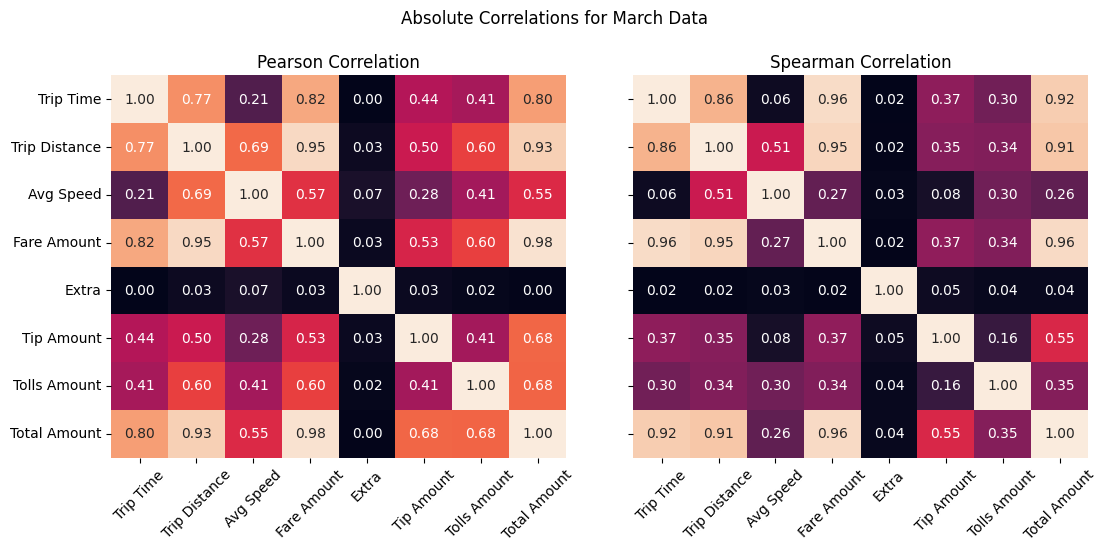

In [69]:
# Correlations between numerical variables for March dataset
fig = correlation_heatmap(march_data, figsize = (12, 6));
fig.suptitle('Absolute Correlations for March Data');

Rather than look at the heatmaps for each dataset individually and try to compare the cells, we will use Fisher's Z-Transform test to test for whether correlations differ between our datasets. For two independent correlations $r_1, r_2$ from datasets of sizes $n_1, n_2$:
$$z = \dfrac{z_1 - z_2}{\sqrt{\dfrac{1}{n_1 - 3} + \dfrac{1}{n_2 - 3}}}$$
where:
$$z_i = \dfrac{1}{2}\ln\left(\dfrac{1 + r_i}{1 - r_i}\right)$$

In other worse, the Fisher's Z-Transform converts each correlation $r_i$ into a z-score, then computes an inter-dataset z-score along with a p-value to test for significant differences between the two correlations.

- Fisher Z-Transformation: https://www.statisticshowto.com/fisher-z/
- Comparing correlation coefficients: https://www.statisticssolutions.com/comparing-correlation-coefficients/

There are 15 significant correlation differences between the January and March datasets for variables with absolute correlation greater than 0.5, and there are 14 significant correlation differences between the May and March datasets for variables with absolute correlation  greater than 0.5.

In [70]:
# Compute fisher z test correlations, returning only significant results, Pearson correlations only
# Filter on correlations with at least moderate magnitude (0.5) in either dataset
fisher_z_summary = fisher_z_test_correlations([jan_data, march_data, may_data],
                                              reference_index = 1,
                                              return_significant_only = True,
                                              dataset_names = ['January', 'March', 'May'],
                                              corr_magnitude_thresh = 0.5)['summary']
# Show full summary table
fisher_z_summary

,variable_1,variable_2,reference_dataset,comparison_dataset,r_reference,r_comparison,z_score,p_value,significant
0,trip_distance,trip_time,March,January,0.768073,0.796174,-102.428718,0.000000e+00,True
1,avg_speed,trip_distance,March,January,0.685122,0.721238,-101.087754,0.000000e+00,True
2,avg_speed,fare_amount,March,January,0.567017,0.614741,-103.739439,0.000000e+00,True
3,avg_speed,total_amount,March,January,0.548776,0.602867,-114.511442,0.000000e+00,True
4,fare_amount,trip_time,March,January,0.824963,0.839228,-65.586985,0.000000e+00,True
5,fare_amount,trip_distance,March,January,0.949615,0.948651,13.747515,0.000000e+00,True
6,fare_amount,tip_amount,March,January,0.531727,0.569165,-75.957839,0.000000e+00,True
7,fare_amount,tolls_amount,March,January,0.600139,0.628253,-63.834263,0.000000e+00,True
8,fare_amount,total_amount,March,January,0.976357,0.979073,-87.217905,0.000000e+00,True
9,tip_amount,trip_distance,March,January,0.499081,0.551579,-102.573437,0.000000e+00,True


Looking at the differences from March to the other datasets, we see that correlations are stronger across the board in January. In particlar, trip time is even more strongly correlated with trip distance, total amount, and fare amount, and tip amount is more strongly correlated with trip distance, possibly due to a higher prevalence of credit card tips.

May also shows stronger correlations for trip time with trip distance, total amount, and fare amount compared to March. However, there is a huge decrease in correlation between tip amount and fare/total amount. Either people stopped tipping after COVID-19, or the increase in e-hail usage created a large disconnect between tips and fares. Maybe there were lower tips through the e-hail apps, or passengers more frequently tipped with cash which went unreported.

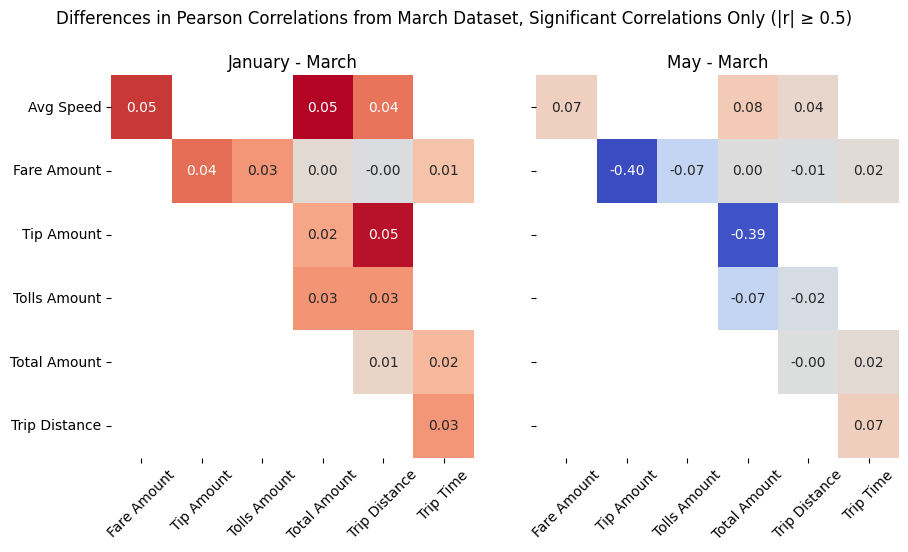

In [71]:
# Plot the important differences visually using heatmaps
fig = plot_correlation_differences(fisher_z_summary, figsize = (5, 6));
fig.suptitle('Differences in Pearson Correlations from March Dataset, Significant Correlations Only (|r| ≥ 0.5)');

One method to check for multicollinearity is the Variance Inflation Factor (VIF). The VIF for a feature is calculated by fitting a linear model to that feature using all of the other features and then calculating 1 divided by 1 - $R^2$. In other words, for feature $i$, the VIF is:
$$VIF_i = \dfrac{1}{1 - R_{i}^2}$$
This can also be calculated simultaneously for all of the features by taking the diagonal values of the inverted Pearson correlation matrix. VIF values above 4 generally indicates some multicollinearity, while VIF values above 10 implies significant multicollinearity. Multicollinearity can be addressed by removing one or more of highly correlated features, since the information is redundant, by using PCA transformations, or by using regularized models such as Ridge regression.

- Variance inflation factor as diagonal of inverse correlation matrix: https://math.stackexchange.com/questions/2681911/prove-vif-of-jth-predictor-is-jth-diagonal-entry-of-inverse-of-correlation-matri
- Variance inflation factor interpretations: https://www.datacamp.com/tutorial/variance-inflation-factor

There is severe multicollinearity in fare amount and total amount, with higher multicollinearity present in tip amount and trip distance. The incredibly high VIF scorse for fare amount and total amount imply that these two features likely contain almost identical information. Note that VIF can be recalculated after removing a variable to achieve different results on the reduced feature set.

In [72]:
# Baseline VIF with all continuous variables and no transformations
calculate_multi_VIF(
    dataframes = [jan_data, march_data, may_data],
    dataset_names = ['January', 'March', 'May'],
    columns = [
        'trip_distance', 'avg_speed', 'fare_amount',
        'extra', 'tip_amount', 'tolls_amount', 'total_amount'
    ]
)

,January,March,May
trip_distance,14.598620,15.122594,12.013958
avg_speed,2.394659,2.228696,2.182799
fare_amount,241.522648,192.085255,163.516437
extra,1.153578,1.151567,1.268691
tip_amount,15.416880,13.047412,6.204972
tolls_amount,6.693949,5.240305,4.678709
total_amount,367.925711,279.415644,186.965636


### Categorical Variables (Associations and Kruskal-Wallis)

There is no direct concept of correlation between categorical variables, only that of association. Typically, the $\chi^2$ (Chi-Squared) test for indepdence is used, but $\chi^2$ does not provide any information about how strongly two variables are associated.

Cramer's V Statistic is used to measure the association between two categorical variables and is based off of the $\chi^2$ statistic. The formula for Cramer's V (usually denoted $\phi_c$) is:

$$\phi_c = \sqrt{\dfrac{\chi^2}{N(k-1)}}$$

where $\chi^2$ is the Chi-statistic, $N$ is the sample size, and $k - 1$ is the length of the minimum dimension of the cross-tab (min of rows or columns) and is often called the degrees of freedom. Cramer's V tests for association, with 0 meaning no association and 1 meaning perfect association between the two variables; however, it is difficult to interpret the strength of the association as it is not perfectly linear and is dependent upon the degrees of freedom $k$.

This is fixed by converting the Cramer's V statistic to Cohen's omega $\omega$. This is done with the following formula:

$$\omega = \phi_c \sqrt{k - 1} = \sqrt{\dfrac{\chi^2}{N}}$$

Cohen's omega is not bound, but it is interpretable. Generally, Cohen's omega values between 0.1-0.3 indicates a low effect strength, 0.3-0.5 indicates a moderate effect strength, and 0.5 or greater indicates a large effect strength.

Reference: Cohen, J. (1988). Statistical power analysis for the behavioral sciences (2nd ed)

The strongest associations between categorical variables are with Rate Code ID. Congestion Surchage, Drop Off Location ID, Pick Up Location ID, and MTA Tax are all strongly associated with Rate Code ID. This makes sense, as the Rate Code is determined by the starting and ending locations; the MTA tax is applied based on ending destination; and the congestion surcharge varies between Group and non-Group rides.

Pick up and drop off location IDs are strongly associated, which makes sense. Certain paths are very common, such as to and from various airports. Pickup hour and payment type are also moderately associated with the pick up and drop off zones, suggesting important geographical influences on taxicab activity and customer type.

Vendor ID is strongly associated with pick up location ID and weakly associated with rate code, which suggests that certain vendors are more likely to operate within certain areas of the city.

Passenger count is only weakly associated with Vendor ID and unassociated with any of the other categorical variables. This is surprising until considering that 76% of all rides have only 1 passenger, meaning there is little influence from the other categorical variables on the number of passengers.

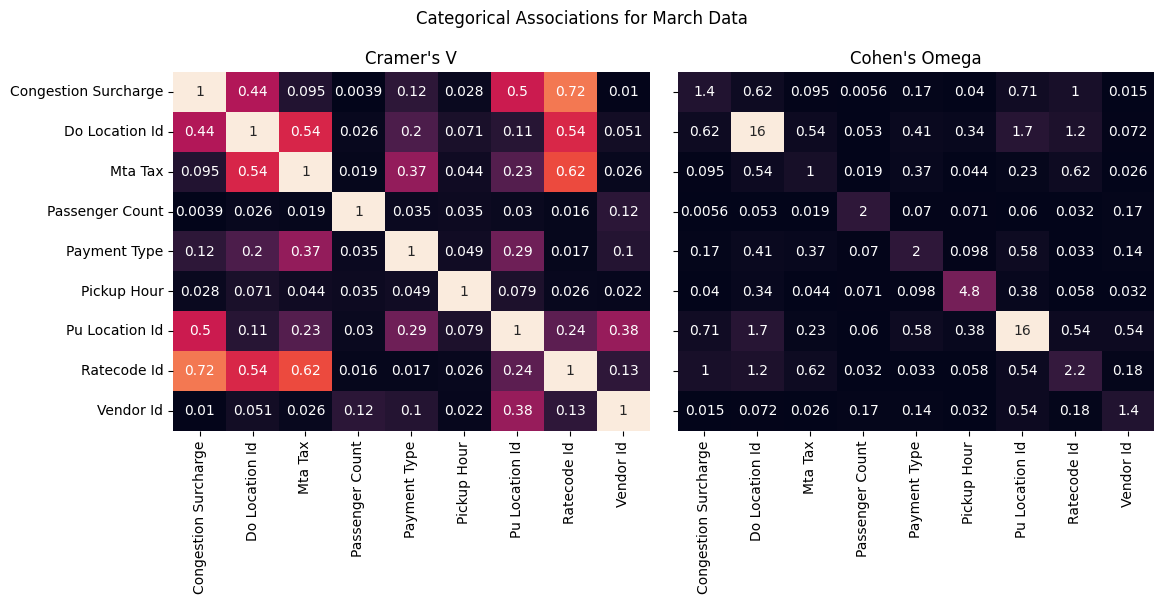

In [73]:
# Cramer's V and Cohen's Omega associations for categorical variables in March dataset
fig = association_heatmap(march_data.select_dtypes(['object', 'category']));
fig.suptitle('Categorical Associations for March Data', y = 1.02);

There is no direct method for calculating p-value significances between associations, so instead, only the direct differences between datasets in significant associations will be considered ($\omega \geq 0.1$).

Most of the associations are similar between the January and March datasets, except for between vendor ID and pick up location and between vendor ID and rate code ID, which have gone from strongly associated to completely unassociated. The reasons for this reduction in association is unclear, although there was one vendor in the March dataset that was missing in the January dataset, which may account for this reduction in association.

Many of the associations have changed in the May dataset compared to the March dataset. Drop off location, payment type, and vendor ID have increased in association with most other categorical variables, while MTA tax and rate code ID have decreased in association with most other variables. This is probably due to the fact that rate codes and MTA tax are locked in during e-hails, which increased greatly in proportion in the May dataset, leading to greater similarity across the data for these features.

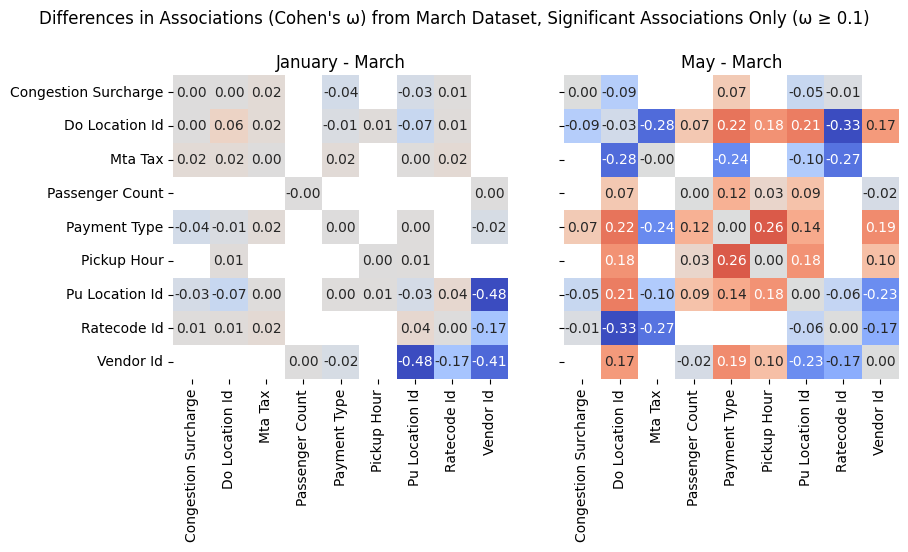

In [74]:
# Plot the important differences visually using heatmaps
fig = plot_association_differences(
    datasets = [
        march_data.select_dtypes(['object', 'category']),
        jan_data.select_dtypes(['object', 'category']),
        may_data.select_dtypes(['object', 'category'])
    ],
    dataset_names = ['March', 'January', 'May'], figsize = (5, 6)
);

fig.suptitle('Differences in Associations (Cohen\'s ω) from March Dataset, Significant Associations Only (ω ≥ 0.1)');

To test for statistical relations between categorical and continuous variables, a Kruskal-Wallis test can be performed. The Kruskal-Wallis test is non-parametric, so the only assumption for the data is that it is ordinal. The Kruskal-Wallis null hypothesis tests for whether each group has the same means on ranks, rather than each of the data points themselves. This is often described as testing whether the groups have the same median. The H-statistic used in Kruskal Wallis is calculated by:

$$H = \dfrac{12}{N(N+1)}\sum_{i=1}^k \dfrac{R_i^2}{n_i} - 3(N + 1)$$

where $N$ is the total sample size, $k$ is the number of groups, $R_i$ is the sum of ranks for group $i$, and $n_i$ is the sample size of group $i$. Each data point is given a rank based on sorting all of the data points ordinally. The rank sum for the group is thus the sum of ranks for each data point within that group.

The significance value is calculated using the $\chi_2$ distribution, and significant values ($p \leq 0.05$) indicate that at least one group is statistically unlikely to have the same mean on ranks, implying that the categorical variable has some influence on the continuous variable.

- Kruskal-Wallis Test: https://library.virginia.edu/data/articles/getting-started-with-the-kruskal-wallis-test

For the sake of brevity, the Kruskal-Wallis test will only be tested on categorical variables with respect to the target variable: trip time.

Only significant variables ($p \leq 0.05$) are shown, with the corresponding H-statistic as the value.

As can be seen, each of the categorical variables is considered significant with respect to trip time in the March dataset; however, the H values of pick up location, drop off location, and rate code ID are overwhelmingly high compared to the other variables. The next most useful variables are payment type and pick up hour.

For the January dataset, the same trends appear with generally higher H values, except for vendor ID which has a lower H value.

For the May dataset, rate code ID has lost almost all of its value (3,878 vs. 144,445), as well as MTA tax (1,936 vs. 21,609). Pick up location (65,018 vs. 320,246) and drop off location (113,319 vs. 469,785) are still important, but much less so. Congestion surcharge and pick up hour are less important and payment type (65,062 vs. 44,955) and vendor ID (10,421 vs. 1,529) have become much more important. Drop off location is still the variable with the highest H value, but now payment type is the second highest H value followed by pick up location.

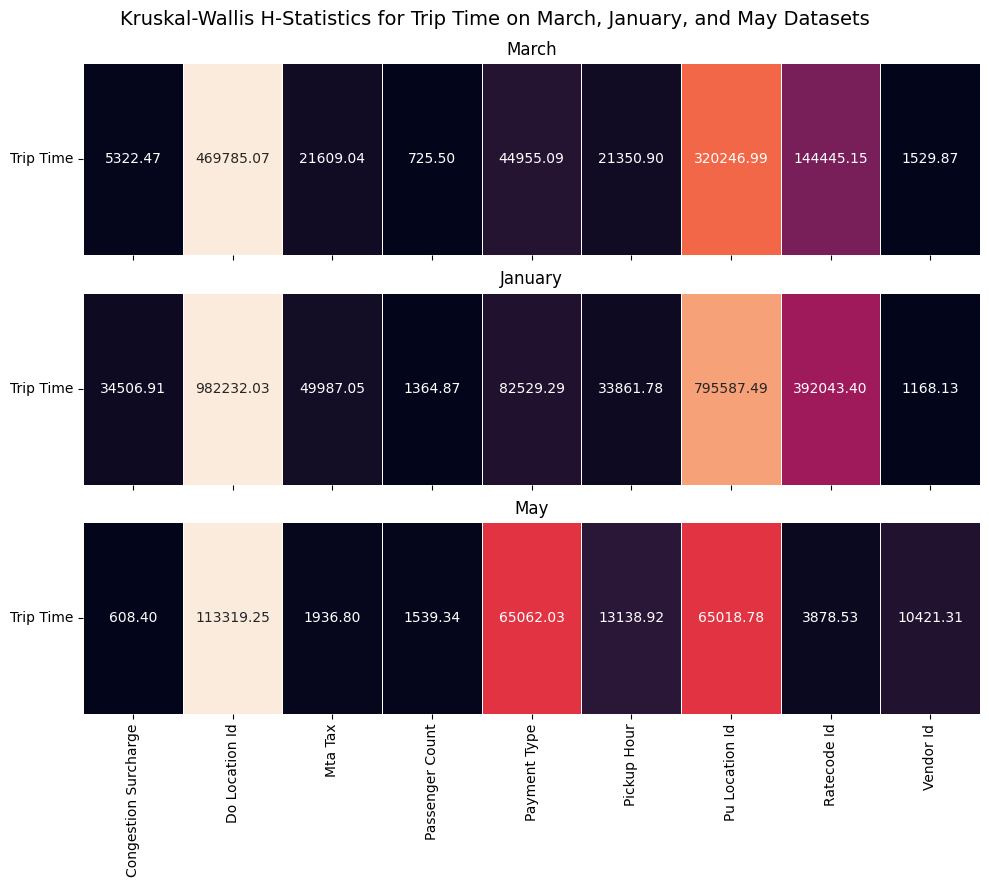

In [75]:
# Kruskal Wallis test for relationship between categorical variables and trip time on March dataset
plot_kruskal_wallis_heatmap(
    [march_data, jan_data, may_data],
    continuous_var = 'trip_time',
    dataset_names = ['March', 'January', 'May'],
    title = 'Kruskal-Wallis H-Statistics for Trip Time on March, January, and May Datasets'
);

## Graphical Analysis

For datasets of this size, it is not feasible to investigate every single feature. Based on the previous feature importance analysis, the following variables will be investigated more closely to view relationships across the three datasets due to high correlation coefficients and Kruskal-Wallis statistics.

- Trip Metrics: Trip Distance and Trip Time
- High Collinearity: Fare Amount and Total Amount
- Payment and Billing Information: Payment Type and Rate Code
- Taxi Trip Pathing: Pick Up Location and Drop Off Location

### Trip Metrics: Trip Distance and Trip Time

#### Trip Time Distributions

$$
\begin{array}{lccc}
\textbf{Timeframe} & \textbf{January} & \textbf{March} & \textbf{May} \\
\hline
\leq 12 \text{ minutes} & 57.1\% & 57\% & 64\% \\
12-30 \text{ minutes} & 36.5\% & 36.7\% & 30\% \\
30-60 \text{ minutes} & 6\% & 5.8\% & 5.7\% \\
\geq 60 \text{ minutes} & 0.4\% & 0.5\% & 0.3\%
\end{array}
$$


Very short trips are more common in the May dataset, while longer trips are more common in the January and March datasets. This is likely due to a decrease in traffic during May, as the streets were much less busy several months into the COVID-19 pandemic. Lower traffic means that taxis can drive faster and are less likely to get stuck, resulting in lower trip times.

All of the data is heavily right-skewed, and considering the amount of trips within only 1 hour, it may be worthwhile to further prune the data. Even though 0.5% of the currently cleaned March dataset is about 15,000 records, models may struggle to train on the rare upper-bounded data. A different solution is to use log transformation.

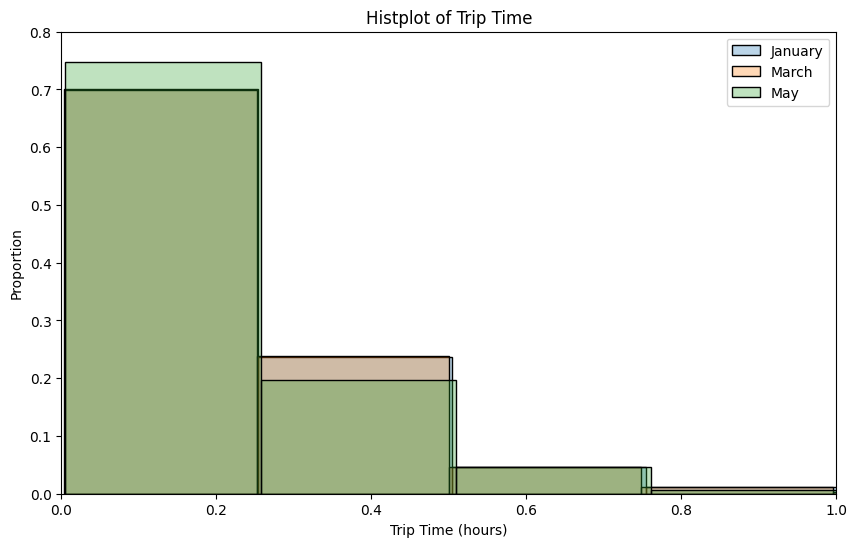

In [76]:
# Distribution of trip times
ax = overlay_plots(
    custom_histplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'trip_time', # variable to plot
        binwidth = 0.25, # use 1/4 hour binwidths for comparison across datasets
        xlabel = 'Trip Time (hours)', # clean up x-label
        xlim = [0, 1] # only about 0.5% of trips are longer than 1 hours [March data] 
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Histplot of Trip Time', # plot title
    figsize = (10, 6) # control figsize
);

Log-transforming trip times removes a large amount of right-skewness, although it does not eliminate it completely. Only 0.2% of the January dataset, 0.3% of the March dataset, and 0.15% of the May dataset have log-transformed trip times greater than 0.75. This is a much more reasonable set of bounds to use, and in combinations with the reduced skew, this log-transformed response variable should make modeling more effective.

For all future analysis, the log-transformed trip time will be used.

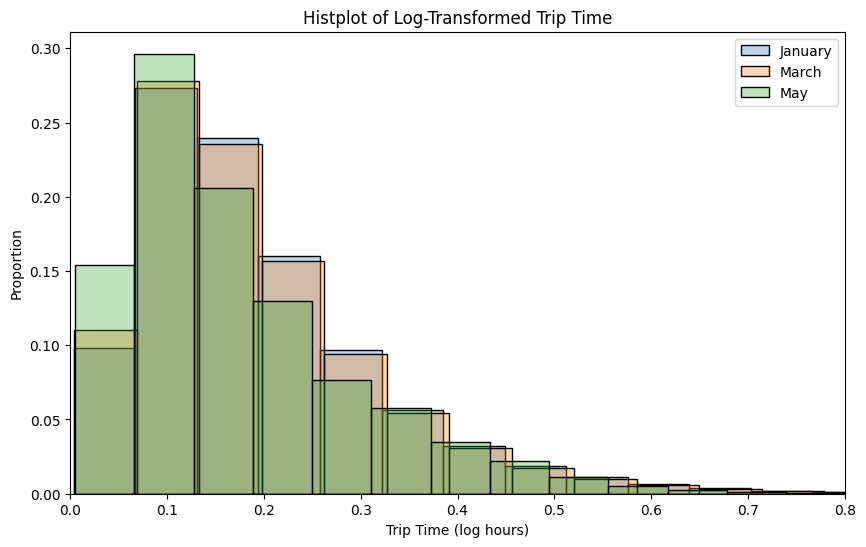

In [77]:
# Distribution of log-transformed trip times
ax = overlay_plots(
    custom_histplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'trip_time', # variable to plot
        log1p = True, # apply log transportation
        xlabel = 'Trip Time (log hours)', # clean up x-label
        xlim = [0, 0.75] # only about 0.3% of trips are longer than 0.75 log hours [March data]
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Histplot of Log-Transformed Trip Time', # plot title
    figsize = (10, 6) # control figsize
);

#### Trip Distance Distributions

$$
\begin{array}{lccc}
\textbf{Distance} & \textbf{January} & \textbf{March} & \textbf{May} \\
\hline
\leq 2.5 \text{ miles} & 69.4\% & 68.1\% & 57.6\% \\
2.5-5 \text{ miles} & 16.8\% & 18.1\% & 20.2\% \\
5-15 \text{ miles} & 10.6\% & 11\% & 18.2\% \\
\geq 15 \text{ miles} & 3.2\% & 2.7\% & 4.1\%
\end{array}
$$

The January and March datasets exhibit similar distributions of trip distances, with most trips traversing less than 2.5 miles. The May dataset had fewer very short trips ($\leq$ 2.5 miles) which makes sense as passengers were more likely to practice social distancing and avoid sitting in a confined space with others unless necessary. Thus, passengers were more likely to walk short distances during the height of COVID-19. There was a higher proportion of medium to long trips in the May dataset, although this is likely more of a consequence of the lower proportion of short trips rather than an indication of longer trips being preferential.

It should be noted that trip times were generally lower in May despite trip distances being longer, further implying that taxis were able to attain a higher average speed in May due to lower amounts of traffic.

Trip distance displays a large amount of right-skewness, and so it is likely worth log-transforming trip distance to try to remove this skewness and make the data more normal.

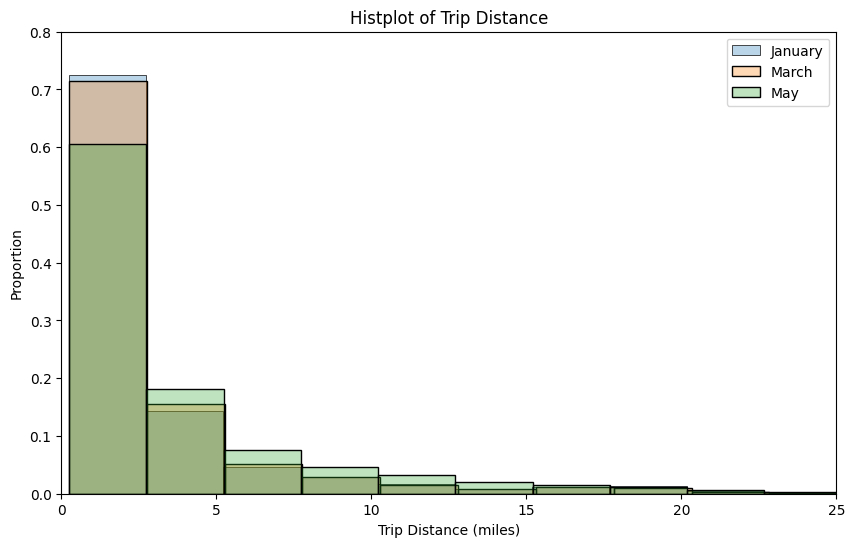

In [78]:
# Distribution of trip distances
ax = overlay_plots(
    custom_histplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'trip_distance', # variable to plot
        binwidth = 2.5, # use 2.5 mile binwidths for comparison across datasets
        xlabel = 'Trip Distance (miles)', # clean up x-label
        xlim = [0, 25] # only about 0.01% of trips are longer than 25 miles [March data] 
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Histplot of Trip Distance', # plot title
    figsize = (10, 6) # control figsize
);

Log-transforming trip distances removes a large amount of right-skewness, although it does not eliminate the skewness completely. Only 802 records from the January dataset (0.012%), 390 records from the March dataset (0.013%), and 181 records from the May dataset (0.054%) have log-transformed trip distances greater than 3.7. This is a much more reasonable set of bounds to use, and in combinations with the reduced skew, this log-transformed trip distance should be more useful for modeling.

Future analysis using trip distances will use the log-transformed version.

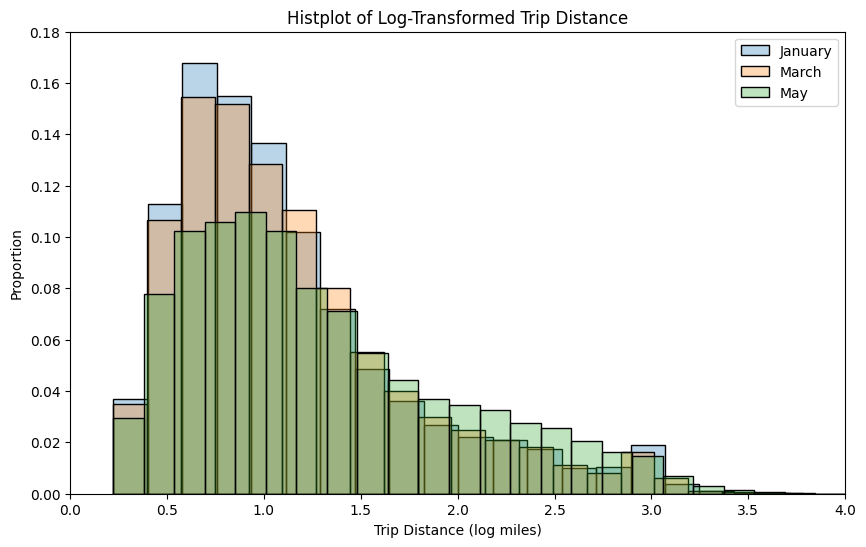

In [79]:
# Distribution of log trip distances
ax = overlay_plots(
    custom_histplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'trip_distance', # variable to plot
        log1p = True, # apply log transformation
        xlabel = 'Trip Distance (log miles)', # clean up x-label
        xlim = [0, 3.7] # only about 0.01% of trips are longer than 3.7 log miles [March data]
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Histplot of Log-Transformed Trip Distance', # plot title
    figsize = (10, 6) # control figsize
);

#### Trip Distance vs. Trip Time

For the January and March datasets, the trip time and trip distance show a clear correlation. Although there is a higher density of data points where both trip distance and trip time are low, the most dense areas continue in a somewhat linear manner until reaching the medium and high values of trip time and trip distance, where the relationship becomes somewhat exponential. Depending on the viewer, the joint distribution could be considered exponential for the entire dataset. Regardless, these variables show a clear relationship with one another.

The May dataset has a slightly different joint distribution due to the presence of more trips with longer distance but shorter length. Instead of a vaguely exponential relation, the relation is almost linear. This aligns with the higher Pearson correlation coefficient observed between trip distance and trip time in the May dataset.

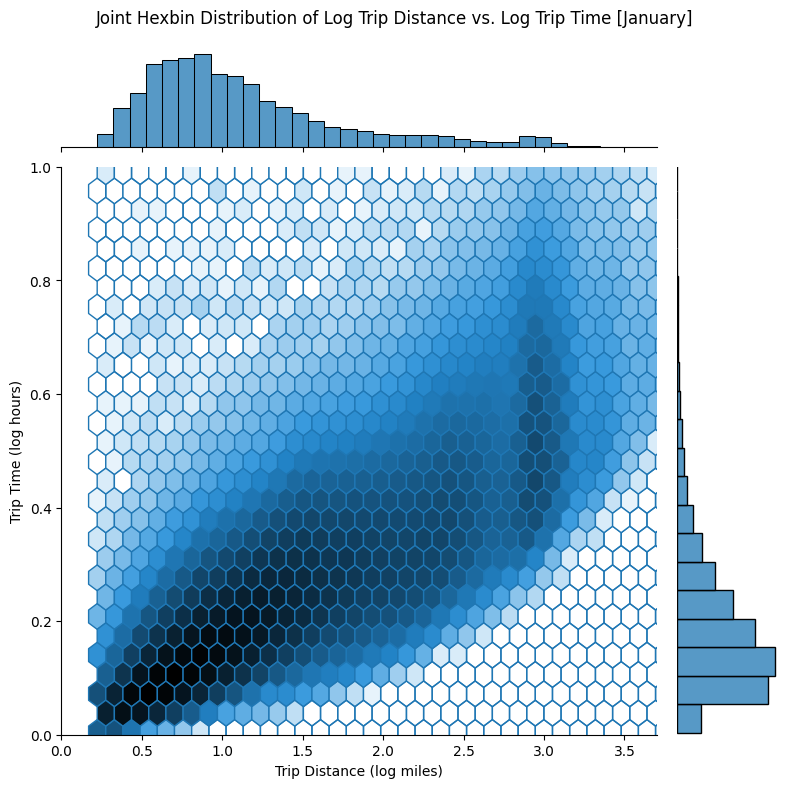

In [80]:
# Joint distribution of log trip distance and log trip time for the January dataset
custom_hexbin(
    jan_data, # Dataset
    x = 'trip_distance', y = 'trip_time', # Variables
    log1p_x = True, log1p_y = True, # Apply log transformations
    xlim = [0, 3.7], ylim = [0, 1], # Apply axis limits as discovered during univariate analysis
    figsize = 8, color = plt.get_cmap("tab10").colors[0], # Figure size and colors
    bins = 'log', binwidth_x = 0.1, binwidth_y = 0.05, # Change binning strategy for hexbin and marginal histplots
    title = 'Joint Hexbin Distribution of Log Trip Distance vs. Log Trip Time [January]',
    xlabel = 'Trip Distance (log miles)', ylabel = 'Trip Time (log hours)'
);

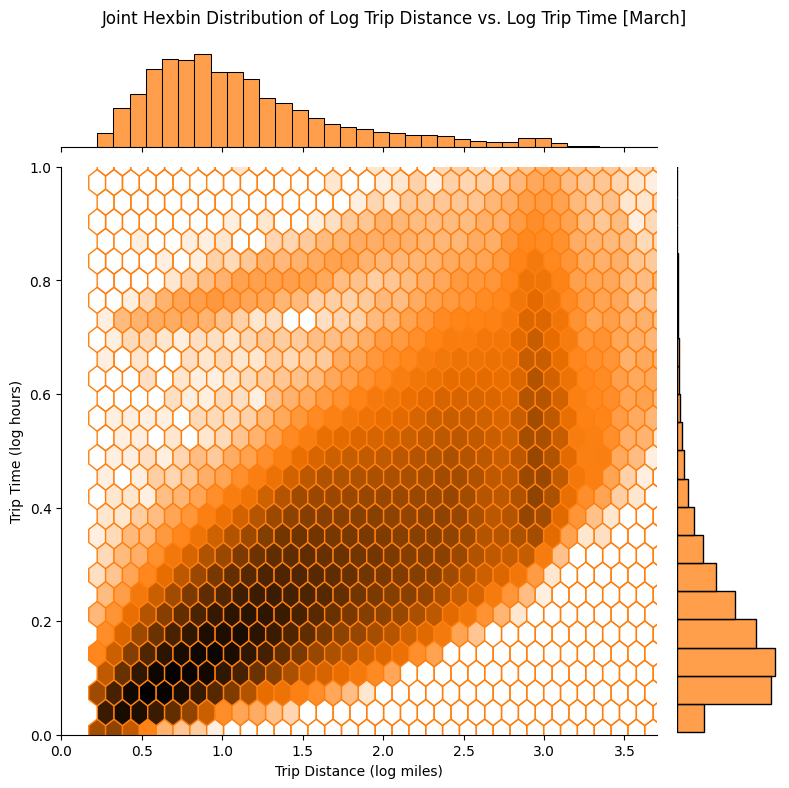

In [81]:
# Joint distribution of log trip distance and log trip time for the March dataset
custom_hexbin(
    march_data, # Dataset
    x = 'trip_distance', y = 'trip_time', # Variables
    log1p_x = True, log1p_y = True, # Apply log transformations
    xlim = [0, 3.7], ylim = [0, 1], # Apply axis limits as discovered during univariate analysis
    figsize = 8, color = plt.get_cmap("tab10").colors[1], # Figure size and colors
    bins = 'log', binwidth_x = 0.1, binwidth_y = 0.05, # Change binning strategy for hexbin and marginal histplots
    title = 'Joint Hexbin Distribution of Log Trip Distance vs. Log Trip Time [March]',
    xlabel = 'Trip Distance (log miles)', ylabel = 'Trip Time (log hours)'
);

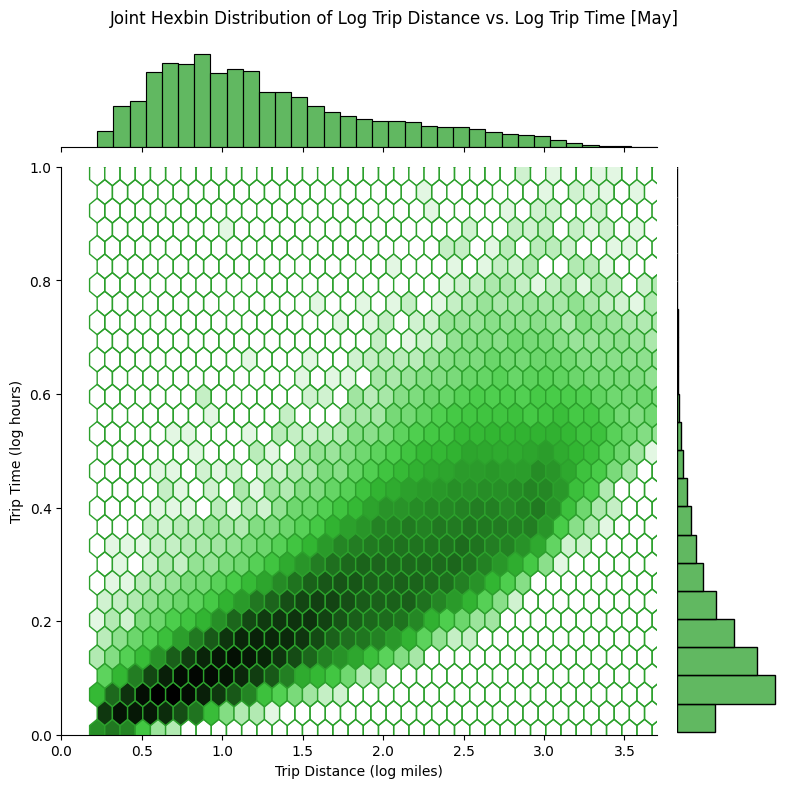

In [82]:
# Joint distribution of log trip distance and log trip time for the May dataset
custom_hexbin(
    may_data, # Dataset
    x = 'trip_distance', y = 'trip_time', # Variables
    log1p_x = True, log1p_y = True, # Apply log transformations
    xlim = [0, 3.7], ylim = [0, 1], # Apply axis limits as discovered during univariate analysis
    figsize = 8, color = plt.get_cmap("tab10").colors[2], # Figure size and colors
    bins = 'log', binwidth_x = 0.1, binwidth_y = 0.05, # Change binning strategy for hexbin and marginal histplots
    title = 'Joint Hexbin Distribution of Log Trip Distance vs. Log Trip Time [May]',
    xlabel = 'Trip Distance (log miles)', ylabel = 'Trip Time (log hours)'
);

### Payment and Billing Information: Payment Type and Rate Code

#### Taxi Rides by Payment Type

January and March have very similar distributions of payment types, with January having a slightly higher proportion of cash payments and March having a slightly higher proportion of credit payments. Notably, credit is the most common payment type for January and March at around 74%.

May payment types are much more widespread, with a far higher rate of flex use (17% in May compared to 1.2% in March and 1% in January) as well as an increase in cash payments (31% in May compared to 24% in March and January). The higher cash payment use helps to explain the decreased usefulness of tip amount in the May data, as most cash tips are unreported.

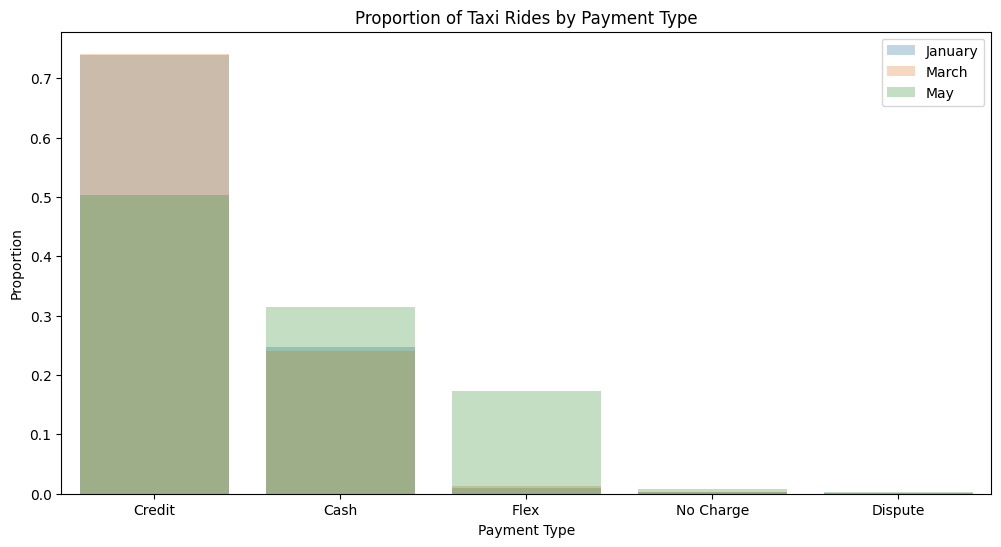

In [83]:
# Taxi rides by payment type
ax = overlay_plots(
    custom_countplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'payment_type', # variable to plot
        stat = 'proportion', # use proportion to allow comparison across different size datasets
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Proportion of Taxi Rides by Payment Type', # plot title
    figsize = (12, 6) # control figsize
);

Flex trips are universally longer across the datasets. This is due to the up-front cost nature of flex payment; the entire trip cost is paid up front so passengers are not likely to leave their trip early. In addition, flex payment requires the trip path to be locked in advance, so planned trips are likely to be longer compared to ad-hoc trips.

There is not a significant difference between trip times for the other categories. It could be worthwhile to convert payment type to a binary feature (Flex or Non-Flex) specifically for the purpose of predicting trip times; however, there may be interactions which are not visible here in this bivariate graph that would be lost by this conversion.

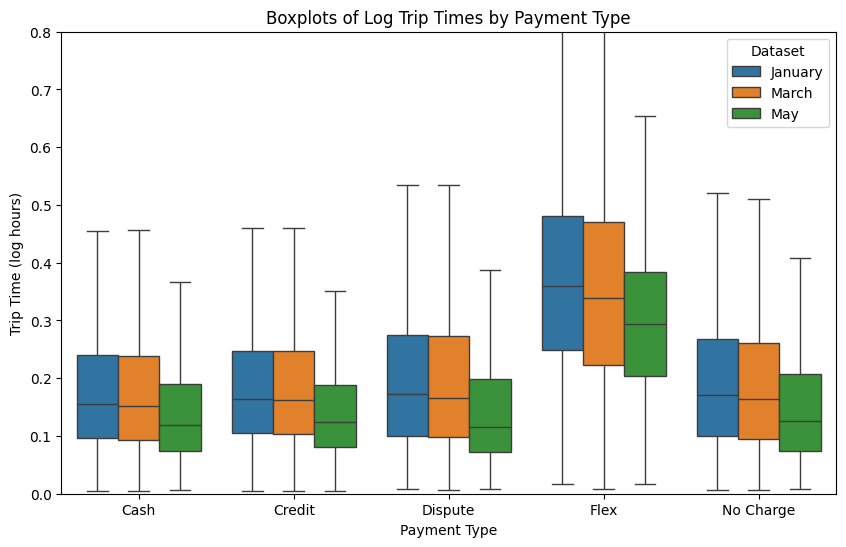

In [84]:
# Log trip times by payment type
ax = hue_plots(
    custom_boxplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'payment_type', # categorical variable to split on
        y = 'trip_time', # target
        orient = 'v', # orientation
        log1p_y = True, # apply log transformation
        ylabel = 'Trip Time (log hours)', # clean up y-label
        ylim = [0, 0.75], # y-axis limits to fit previously discovered limits for log trip time,
        figsize = (12, 6) # control figsize
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Boxplots of Log Trip Times by Payment Type', # plot title
);

#### Taxi Rides by Rate Code

Standard rate code is by far the most common, comprising over 97% of the data for all datasets. January and March contained far more taxi rides using the JFK rate code, but the May data had significantly fewer trips to or from JFK (2.3% in January, 1.8% in March, 0.4% in May). This is understandable as people were reluctant or prevented from traveling during the height of the COVID-19 pandemic, so passengers were unlikely to be using airports.

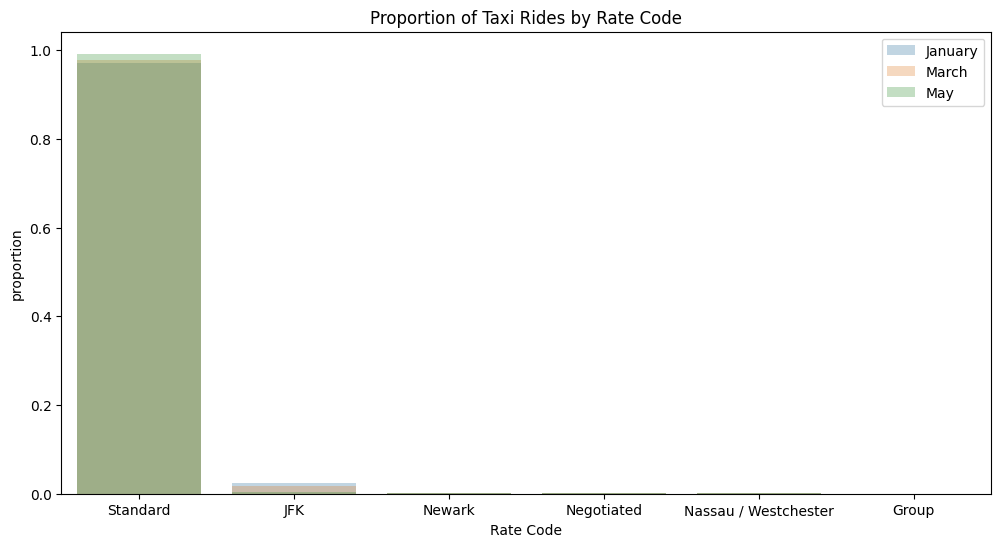

In [85]:
# Taxi rides by rate code
ax = overlay_plots(
    custom_countplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'ratecode_id', # variable to plot
        stat = 'proportion', # use proportion to allow comparison across different size datasets
        ticklabels = [ # fix x-tick labels for better clarity
            'Standard', 'JFK', 'Newark', 'Negotiated', 'Nassau / Westchester', 'Group'
        ],
        xlabel = 'Rate Code' # clean up x-label
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Proportion of Taxi Rides by Rate Code', # plot title
    figsize = (12, 6) # control figsize
);

JFK and Newark trips have the longest trip times, as expected as travel to and from these airports takes more time than intra-city trips. Nassau and Negotiated rate codes are used only for travel outside of the NYC area, and as such, these trips have longer trip times. Standard and Group rates are mostly used for trips within the city, so they represent the shortest trips.

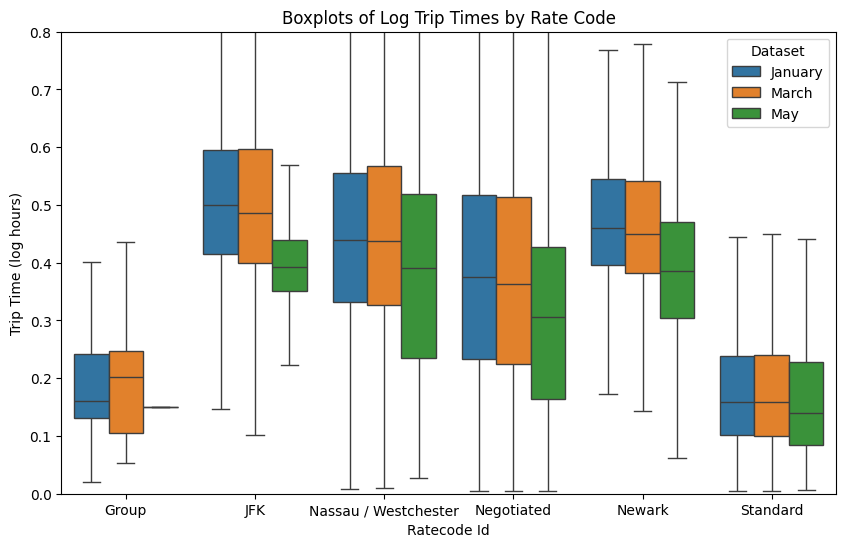

In [86]:
# Log trip times by rate code
ax = hue_plots(
    custom_boxplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'ratecode_id', # categorical variable to split on
        y = 'trip_time', # target
        orient = 'v', # orientation
        log1p_y = True, # apply log transformation
        xticklabels = [ # fix x-tick labels for better clarity
            'Group', 'JFK', 'Nassau / Westchester', 'Negotiated', 'Newark', 'Standard'
        ],
        ylabel = 'Trip Time (log hours)', # clean up y-label
        ylim = [0, 0.75], # y-axis limits to fit previously discovered limits for log trip time,
        figsize = (12, 6) # control figsize
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Boxplots of Log Trip Times by Rate Code', # plot title
);

### High Collinearity and Correlation: Fare Amounts and Total Amounts

#### Tests for Collinearity

The relationship between fare amount and total amount is close to linear, which is expected since the majority of the amount is comprised of the fares. Extra surcharges and tolls should be a small portion of the total amount for most trips. The January and March datasets share a similar pattern for fare and total amount, and the slope of the linear regression is greater than 1 (as a regression line with a slope of 1 would go from the bottom left corner to the top right corner).

The May dataset's regression slope is closer to 1, indicating that an even larger portion of the total amount is captured by the fare amount. This aligns with previous analysis indicating that there were fewer extra charges and tolls during May, as COVID-19 quarantine protocols made out-of-state and out-of-city travel less common, along with higher adoption of flex payment which places all of the cost up front, resulting in fewer miscellaneous surcharges.

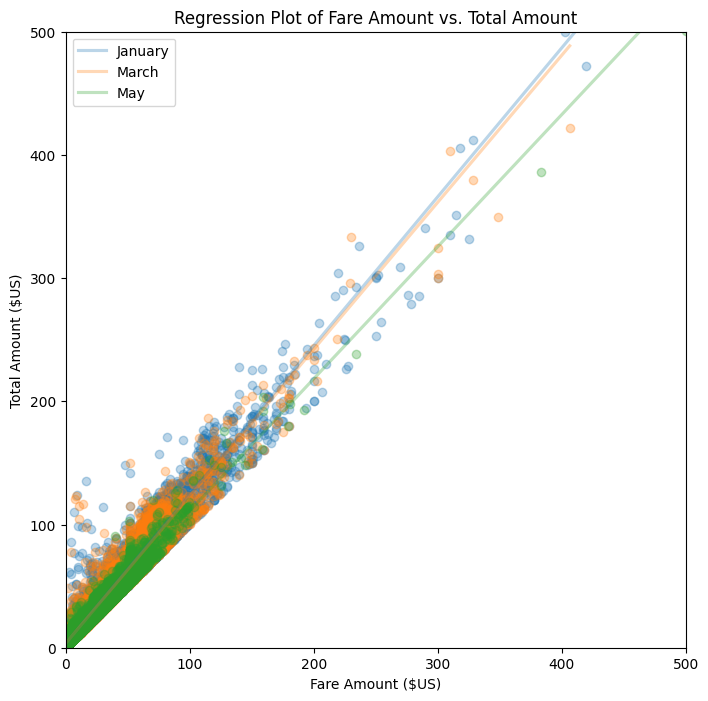

In [87]:
# Comparison between fare amounts and total amounts using scatterplots and linear regression
ax = overlay_plots(
    custom_regplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'fare_amount', # x-variable to plot
        y = 'total_amount', # y-variable to plot
        subsample = 0.1, # only use 10% of the data for subsampling to improve plotting time
        random_state = 42, # set a random state for subsampling for reproducibility
        xlabel = 'Fare Amount ($US)', # clean up x-label
        ylabel = 'Total Amount ($US)', # clean up y-label
        xlim = [0, 500], # constrict x-limits to be square
        ylim = [0, 500] # constrict x-limits to be square
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Regression Plot of Fare Amount vs. Total Amount', # plot title
    figsize = (8, 8) # control figsize to be square to better visually estimate regression slope
);

In all cases, fare amount and total amount contain nearly the same information, and for the purposes of modeling, at least one of these columns should be dropped. Since total amount also captures other surcharges and has a higher VIF, it is probably best to keep the fare amount for having higher separability from other features.

In [88]:
# Baseline VIF with all continuous variables and no transformations
calculate_multi_VIF(
    dataframes = [jan_data, march_data, may_data],
    dataset_names = ['January', 'March', 'May'],
    columns = [
        'trip_distance', 'avg_speed', 'fare_amount',
        'extra', 'tip_amount', 'tolls_amount', 'total_amount'
    ]
)

,January,March,May
trip_distance,14.598620,15.122594,12.013958
avg_speed,2.394659,2.228696,2.182799
fare_amount,241.522648,192.085255,163.516437
extra,1.153578,1.151567,1.268691
tip_amount,15.416880,13.047412,6.204972
tolls_amount,6.693949,5.240305,4.678709
total_amount,367.925711,279.415644,186.965636


Trip distance and fare amount still have high VIF after dropping total amount, which may need to be addressed.

In [89]:
# VIF without total_amount and no transformations
calculate_multi_VIF(
    dataframes = [jan_data, march_data, may_data],
    dataset_names = ['January', 'March', 'May'],
    columns = [
        'trip_distance', 'avg_speed', 'fare_amount',
        'extra', 'tip_amount', 'tolls_amount'
    ]
)

,January,March,May
trip_distance,14.535107,15.115429,11.931101
avg_speed,2.336221,2.190359,2.176782
fare_amount,11.559086,12.357692,9.054611
extra,1.005992,1.007975,1.050841
tip_amount,1.518505,1.423838,1.029442
tolls_amount,1.721941,1.614457,1.510158


By testing VIF scores using only continuous features with at least moderate correlation ($\lvert r \rvert \geq 0.4$), it is possible to test whether fare amount or trip distance has a higher VIF score. The log-transformed fare amount and trip distance are both used since they are both heavily right-skewed distributions. When removing one of these variables from the data, the VIF scores show effectively no multicollinearity among the remaining continuous features.

The difference between the two options is negligble, even if trip distance has a slightly lower VIF on the March dataset. The choice of which to use is dependent upon domain knowledge and choice of dataset. In the January and May datasets, trip distance has a higher VIF, but in the March dataset which is to be used for training, trip distance has a slightly lower VIF. Regardless, both choices are likely equally viable for modeling.

In [90]:
# VIF using only columns with at least medium correlation with trip time, using log fare amount
calculate_multi_VIF(
    dataframes = [jan_data, march_data, may_data],
    dataset_names = ['January', 'March', 'May'],
    columns = ['fare_amount','tip_amount', 'tolls_amount'],
    log1p_columns = ['fare_amount']
)

,January,March,May
fare_amount,1.583520,1.505321,1.283984
tip_amount,1.488271,1.400530,1.023089
tolls_amount,1.442321,1.354745,1.258227


In [91]:
# VIF using only columns with at least medium correlation with trip time, using log trip distance
calculate_multi_VIF(
    dataframes = [jan_data, march_data, may_data],
    dataset_names = ['January', 'March', 'May'],
    columns = ['trip_distance','tip_amount', 'tolls_amount'],
    log1p_columns = ['trip_distance']
)

,January,March,May
trip_distance,1.603626,1.500722,1.306836
tip_amount,1.472338,1.370640,1.021725
tolls_amount,1.471221,1.380561,1.282368


#### Fare Amount Distributions

$$
\begin{array}{lccc}
\textbf{Fare Amount} & \textbf{January} & \textbf{March} & \textbf{May} \\
\hline
\leq 18 \text{ dollars} & 84.4\% & 84.6\% & 78.8\% \\
18-36 \text{ dollars} & 10.8\% & 11.2\% & 14.7\% \\
36-72 \text{ dollars} & 4.6\% & 4\% & 6.2\% \\
\geq 72 \text{ dollars} & 0.2\% & 0.2\% & 0.3\%
\end{array}
$$

Trips during January and March were typically less expensive, while more expensive trips were more common during May. This makes sense given the higher trip distances in the May dataset, as longer trips typically have higher fares. Most trips are less than $18 in all of the datasets.

As with the other continuous variables, Fare Amount is highly right-skewed and is a good candidate for log-transformation.

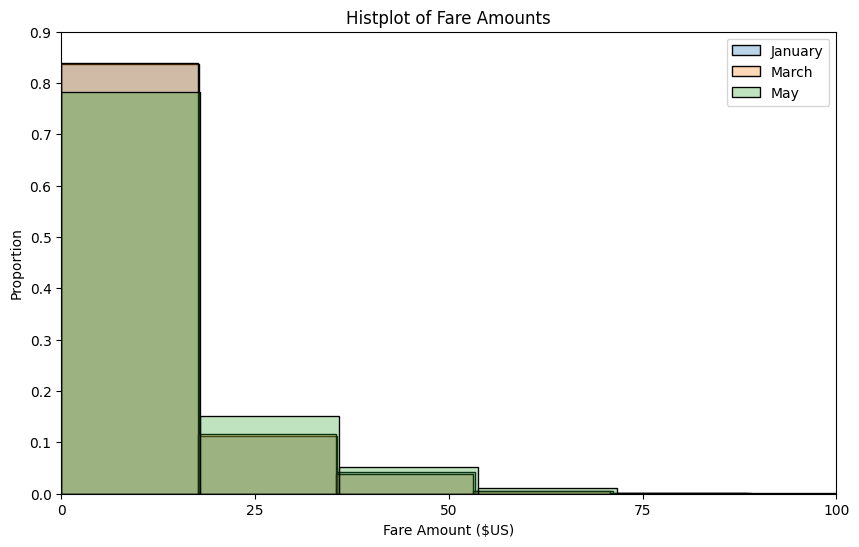

In [92]:
# Distribution of fare amounts
ax = overlay_plots(
    custom_histplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        [
            ('x', 'fare_amount'), # variable to plot
            ('binwidth', 18) # use 18 dollar binwidths for comparison across datasets
        ]
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Histplot of Fare Amounts', # plot title
    figsize = (10, 6) # control figsize
);
ax.set_xlabel('Fare Amount ($US)'); # Clean up x-label
ax.set_xlim([0, 100]); # Constrict x-limits, only about 0.04% of trips have fares greater than $100 [March data]
ax.set_xticks(np.arange(0, 125, 25), np.arange(0, 125, 25)); # Reconstruct ticks because of new axis limits

After log-transformation, most of the right-skewness has disappeared. Fare amounts are almost normally distributed, which is highly desirable and was not something that was able to be accomplished with the other continuous variables analyzed. Only 0.018% of the January dataset, 0.016% of the March dataset, and 0.024% of the May dataset have log fare amounts greater than 5, so restricting the log-transformed data to the (1, 5) range would lose little data and greatly improve the usefulness of the fare amounts as a feature for predictions.

For all further analysis, the log-transformed fare amount will be used instead of the untransformed fare amount.

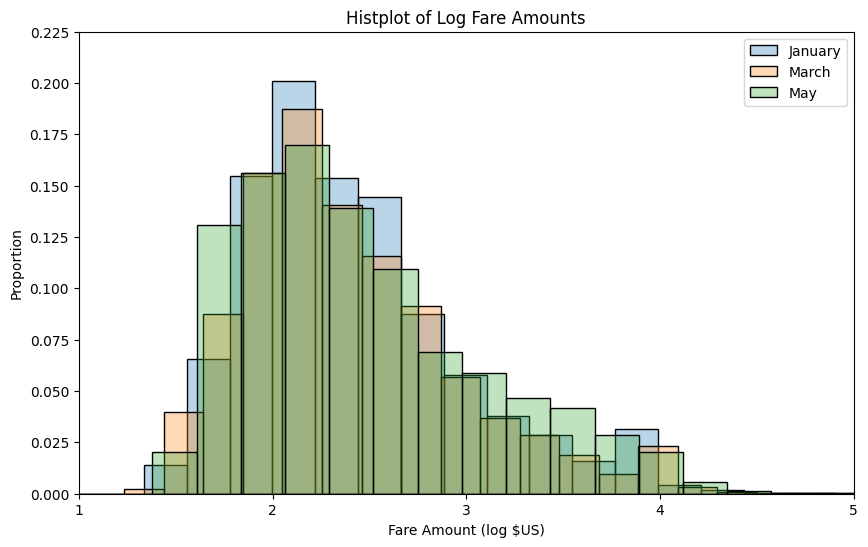

In [93]:
# Distribution of log fare amounts
ax = overlay_plots(
    custom_histplot, # underlying custom plot function
    [jan_data, march_data, may_data], # datasets
    plot_kwargs = dict( # kwargs to pass to underlying plot
        [
            ('x', 'fare_amount'), # variable to plot
            ('log1p', True) # apply log transformation
        ]
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Histplot of Log Fare Amounts', # plot title
    figsize = (10, 6) # control figsize
);
ax.set_xlabel('Fare Amount (log $US)'); # Clean up x-label
ax.set_xlim([1, 5]); # Constrict x-limits, only about 0.01% of trips have log fares greater than 5 [March data]
ax.set_xticks(np.arange(1, 6, 1), np.arange(1, 6, 1)); # Reconstruct ticks because of new axis limits

#### Fare Amount vs. Trip Time

As expected by the VIF analysis performed earlier, log fare amount shows similar joint distribution patterns with log trip time as log trip distance. In all of the datasets, the log fare amount shows a fairly clear exponential (or at least quadratic) relationship with log trip time. However, there is a strange column of high density in the January and March datasets at log fare amount = 4 and a line of moderate density above the main high density cluster from about log fare amount = 2 to log fare amount = 3. These abnormal patterns showed up in the trip distance vs. trip time hexbin plot but to a lesser degree. These patterns are missing from the May dataset.

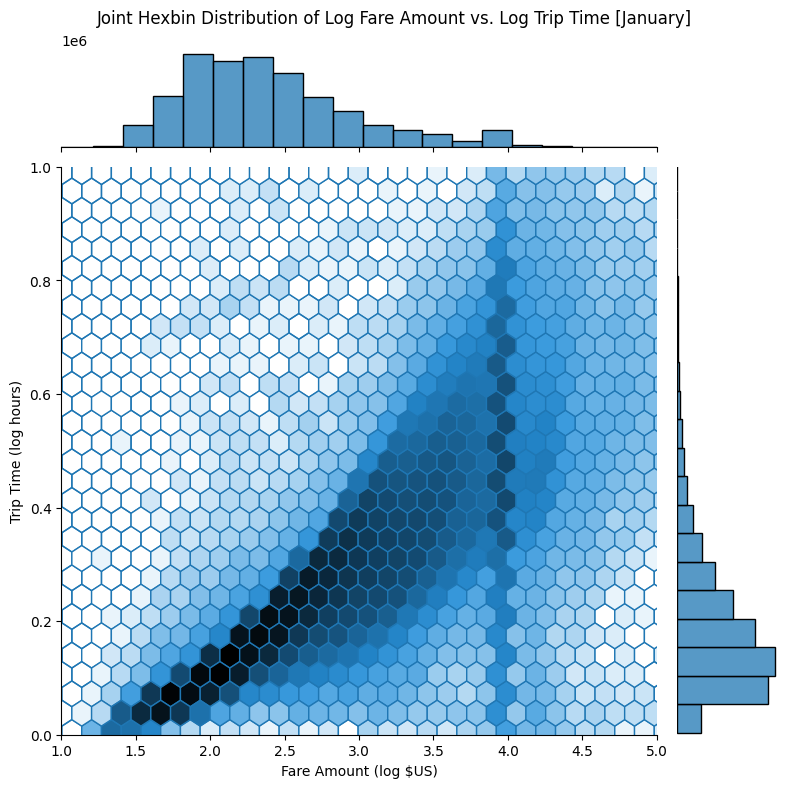

In [94]:
# Joint distribution of log fare amount and log trip time for the January dataset
custom_hexbin(
    jan_data, # Dataset
    x = 'fare_amount', y = 'trip_time', # Variables
    log1p_x = True, log1p_y = True, # Apply log transformations
    xlim = [1, 5], ylim = [0, 1], # Apply axis limits as discovered during univariate analysis
    figsize = 8, color = plt.get_cmap("tab10").colors[0], # Figure size and colors
    bins = 'log', binwidth_x = 0.2, binwidth_y = 0.05, # Change binning strategy for hexbin and marginal histplots
    title = 'Joint Hexbin Distribution of Log Fare Amount vs. Log Trip Time [January]',
    xlabel = 'Fare Amount (log $US)', ylabel = 'Trip Time (log hours)'
);

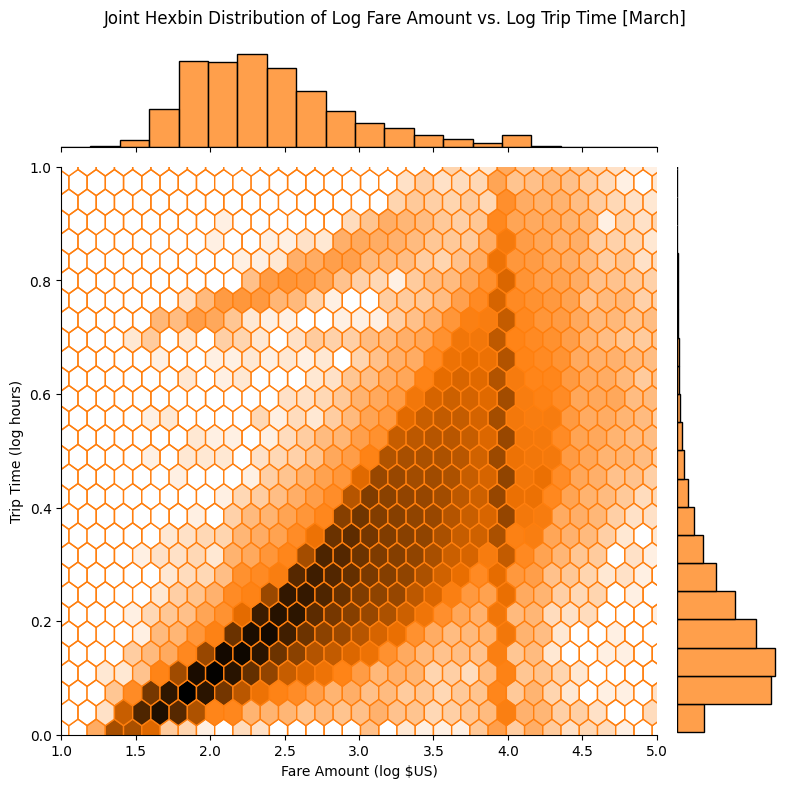

In [95]:
# Joint distribution of log fare amount and log trip time for the March dataset
custom_hexbin(
    march_data, # Dataset
    x = 'fare_amount', y = 'trip_time', # Variables
    log1p_x = True, log1p_y = True, # Apply log transformations
    xlim = [1, 5], ylim = [0, 1], # Apply axis limits as discovered during univariate analysis
    figsize = 8, color = plt.get_cmap("tab10").colors[1], # Figure size and colors
    bins = 'log', binwidth_x = 0.2, binwidth_y = 0.05, # Change binning strategy for hexbin and marginal histplots
    title = 'Joint Hexbin Distribution of Log Fare Amount vs. Log Trip Time [March]',
    xlabel = 'Fare Amount (log $US)', ylabel = 'Trip Time (log hours)'
);

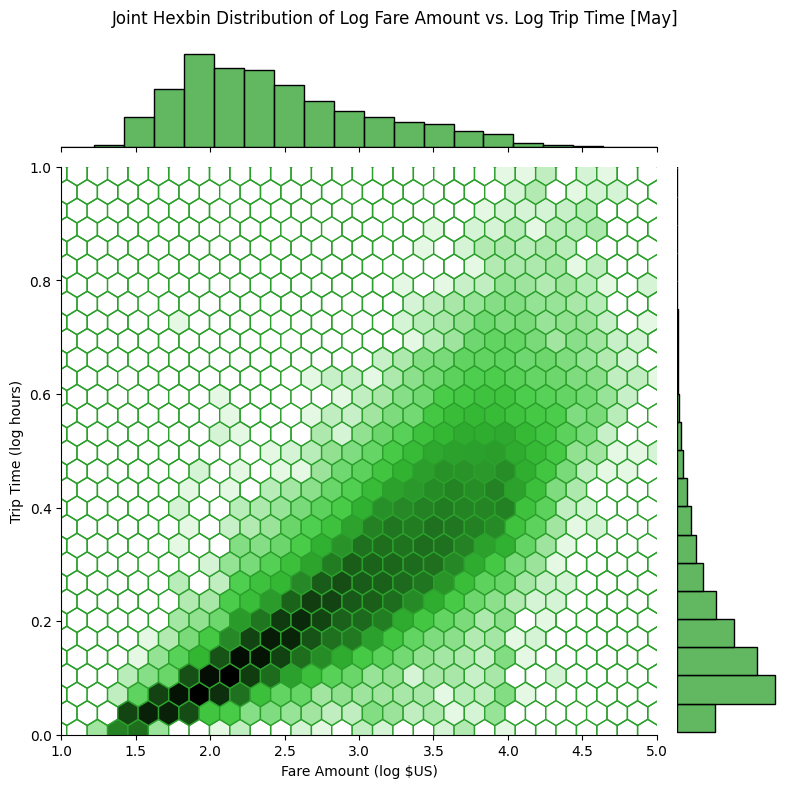

In [96]:
# Joint distribution of log fare amount and log trip time for the May dataset
custom_hexbin(
    may_data, # Dataset
    x = 'fare_amount', y = 'trip_time', # Variables
    log1p_x = True, log1p_y = True, # Apply log transformations
    xlim = [1, 5], ylim = [0, 1], # Apply axis limits as discovered during univariate analysis
    figsize = 8, color = plt.get_cmap("tab10").colors[2], # Figure size and colors
    bins = 'log', binwidth_x = 0.2, binwidth_y = 0.05, # Change binning strategy for hexbin and marginal histplots
    title = 'Joint Hexbin Distribution of Log Fare Amount vs. Log Trip Time [May]',
    xlabel = 'Fare Amount (log $US)', ylabel = 'Trip Time (log hours)'
);

### Taxi Trip Pathing: Pick Up and Drop Off Locations

#### Pick Up Zones

The Upper East Side zones are the most popular pick up zones across the datasets, probably because the Upper East Side is one of the highest population neighborhoods in NYC. In the January and March datasets, Midtown was a popular pick up zone due to being a center for businesses, while Times Square and JFK Airport were likely frequented by tourists.

In the May dataset, the drop in tourism caused a sharp decline in Times Square and JFK frequency, and due to social distancing, business offices in Midtown were no longer being used. Lincoln Square is next to Central Park, while Madison Square has Madison Square Park, both large, open, public spaces where people can congregate while still practicing social distancing, which is probably the main reason these zones were more frequent in the May dataset.

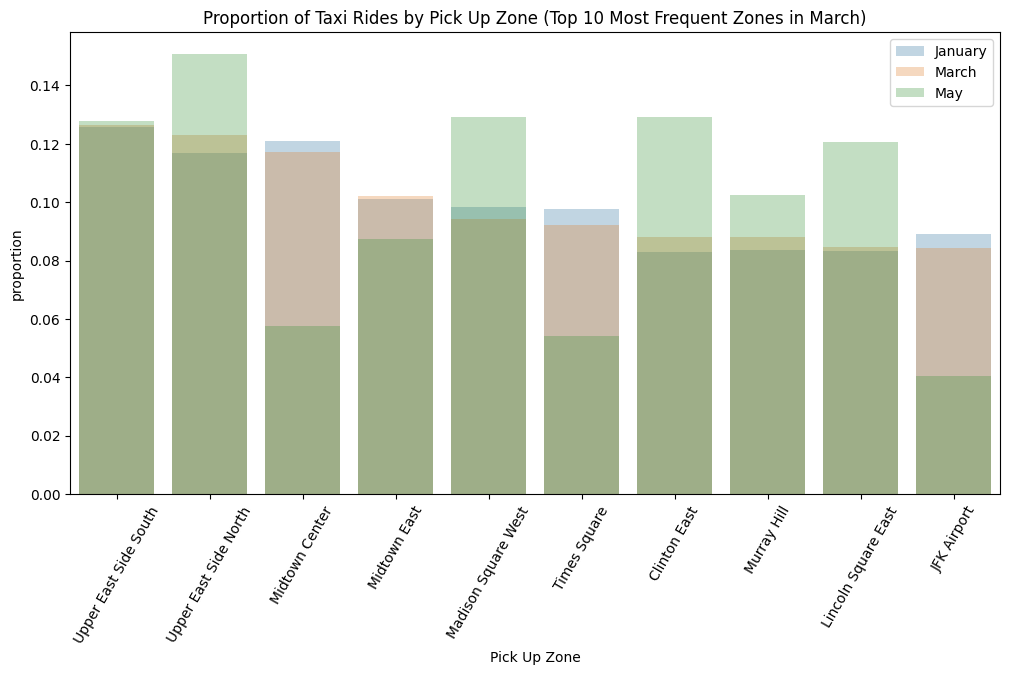

In [97]:
# Top 10 most frequent pick up zones in March
top_10_pu_zones = march_data.pu_location_id.value_counts(normalize = True)[:10].index

# Taxi rides by pick up zone
ax = overlay_plots(
    custom_countplot, # underlying custom plot function
    [
        jan_data[jan_data.pu_location_id.isin(top_10_pu_zones)][['pu_location_id']].astype(int),
        march_data[march_data.pu_location_id.isin(top_10_pu_zones)][['pu_location_id']].astype(int),
        may_data[may_data.pu_location_id.isin(top_10_pu_zones)][['pu_location_id']].astype(int)
    ], # datasets, sliced on 10 most common pick up zones for clarity
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'pu_location_id', # variable to plot
        stat = 'proportion', # use proportion to allow comparison across different size datasets
        plot_order = top_10_pu_zones.tolist(),
        ticklabels = [ # fix x-tick labels for better clarity
            'Upper East Side South', 'Upper East Side North', 'Midtown Center',
            'Midtown East', 'Madison Square West', 'Times Square',
            'Clinton East', 'Murray Hill', 'Lincoln Square East', 'JFK Airport'
        ],
        tick_rotation = 60, # rotate x-tick labels for better clarity
        xlabel = 'Pick Up Zone' # clean up x-label
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Proportion of Taxi Rides by Pick Up Zone (Top 10 Most Frequent Zones in March)', # plot title
    figsize = (12, 6) # control figsize
);

At least among the top 10 most frequent pick up locations in March, almost all pick up locations have similar trip times. However, Upper East Side North stands out as having much higher trip times. This is an observation in the data, although it is not clear why Upper East Side North has dramatically higer trip times, especially compared to Upper East Side South which is geographically adjacent.

Because there are over 200 zones, it is not feasible to visually inspect all of the possible zones. It is also unrealistic to keep all of these zones via one-hot-encoding, and so it is likely that target encoding will be used for the pick up zones which will naturally capture the differences in trip times by zone.

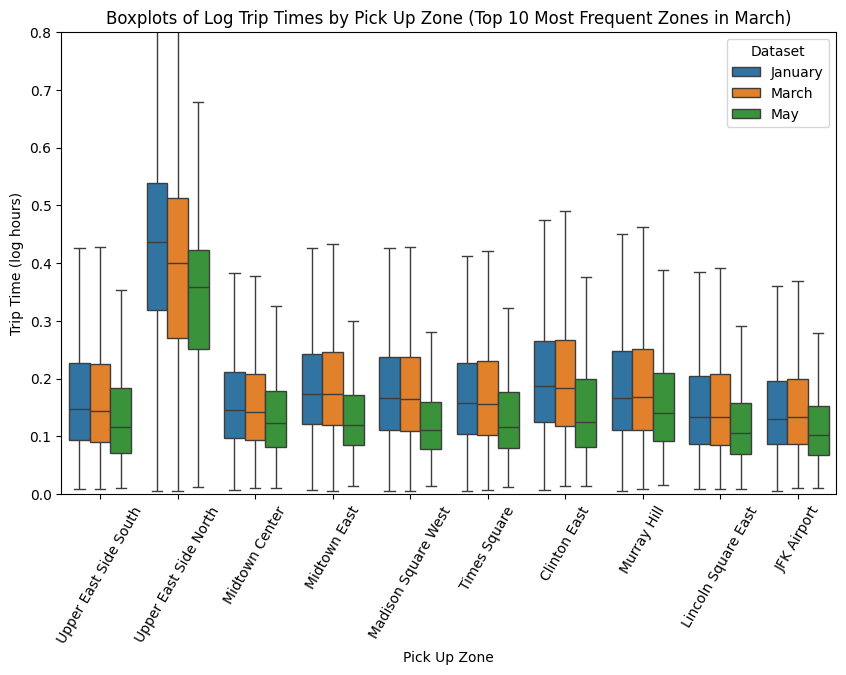

In [98]:
# Log trip times by pick up zone
ax = hue_plots(
    custom_boxplot, # underlying custom plot function
    [
        jan_data[jan_data.pu_location_id.isin(top_10_pu_zones)][['pu_location_id', 'trip_time']]\
            .astype({'pu_location_id': int}),
        march_data[march_data.pu_location_id.isin(top_10_pu_zones)][['pu_location_id', 'trip_time']]\
            .astype({'pu_location_id': int}),
        may_data[may_data.pu_location_id.isin(top_10_pu_zones)][['pu_location_id', 'trip_time']]\
            .astype({'pu_location_id': int})
    ], # datasets, sliced on 10 most common pick up zones for clarity
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'pu_location_id', # categorical variable to split on
        y = 'trip_time', # target
        orient = 'v', # orientation
        log1p_y = True, # apply log transformation
        xticklabels = [ # fix x-tick labels for better clarity
            'Upper East Side South', 'Upper East Side North', 'Midtown Center',
            'Midtown East', 'Madison Square West', 'Times Square',
            'Clinton East', 'Murray Hill', 'Lincoln Square East', 'JFK Airport'
        ],
        tick_rotation = 60,
        xlabel = 'Pick Up Zone',
        ylabel = 'Trip Time (log hours)', # clean up y-label
        ylim = [0, 0.75], # y-axis limits to fit previously discovered limits for log trip time,
        figsize = (12, 6) # control figsize
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Boxplots of Log Trip Times by Pick Up Zone (Top 10 Most Frequent Zones in March)', # plot title
);

#### Drop Off Zones

Unsurprisingly, the most common drop off zones are in similar neighborhoods as the most popular pick up zones. Upper East and West Side zones, as well as Lennox Hill, are home to wealthier individuals who are more likely to use taxis instead of subways or buses to get aroud the city. Murray Hill is also a residential area. Passengers are more likely to take taxis back to their residences after using other public transportation to go out into the city.

Midtown locations hosted many office buildings, and Times Square was a popular tourist destination. It makes sense then that these locations became infrequent in the May dataset, while residential areas became more frequent, as people mostly traveled to and from their homes during the pandemic rather than going to shared offices or tourist areas.

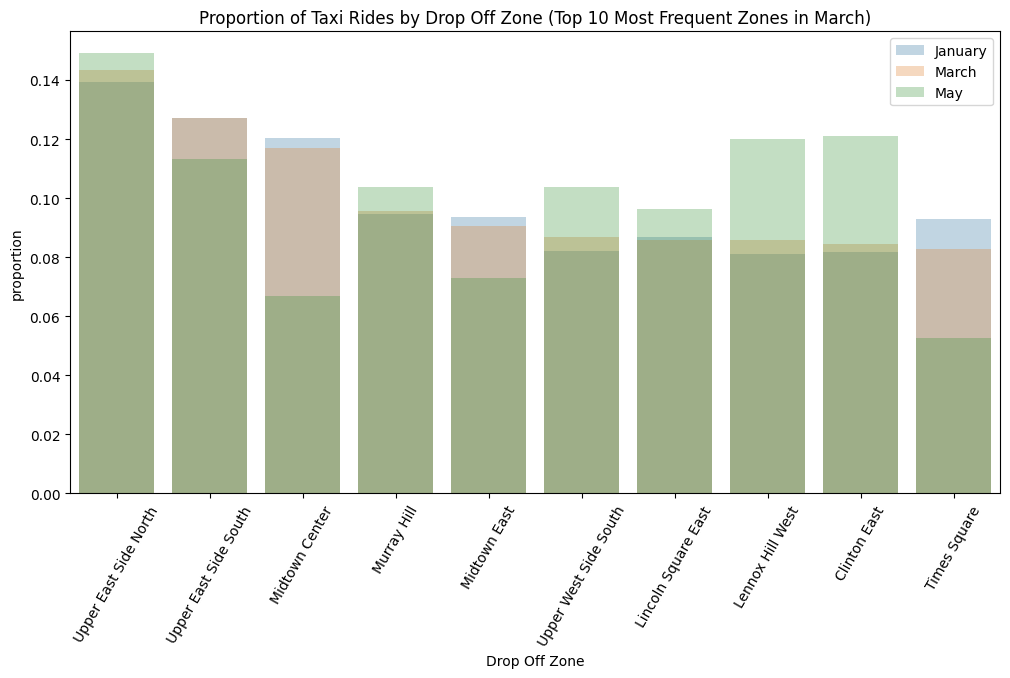

In [99]:
# Top 10 most frequent drop off zones in March
top_10_do_zones = march_data.do_location_id.value_counts(normalize = True)[:10].index

# Taxi rides by drop off zone
ax = overlay_plots(
    custom_countplot, # underlying custom plot function
    [
        jan_data[jan_data.do_location_id.isin(top_10_do_zones)][['do_location_id']].astype(int),
        march_data[march_data.do_location_id.isin(top_10_do_zones)][['do_location_id']].astype(int),
        may_data[may_data.do_location_id.isin(top_10_do_zones)][['do_location_id']].astype(int)
    ], # datasets, sliced on 10 most common drop off zones for clarity
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'do_location_id', # variable to plot
        stat = 'proportion', # use proportion to allow comparison across different size datasets
        plot_order = top_10_do_zones.tolist(),
        ticklabels = [ # fix x-tick labels for better clarity
            'Upper East Side North', 'Upper East Side South', 'Midtown Center',
            'Murray Hill', 'Midtown East', 'Upper West Side South',
            'Lincoln Square East', 'Lennox Hill West', 'Clinton East', 'Times Square'
        ],
        tick_rotation = 60, # rotate x-tick labels for better clarity
        xlabel = 'Drop Off Zone' # clean up x-label
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Proportion of Taxi Rides by Drop Off Zone (Top 10 Most Frequent Zones in March)', # plot title
    figsize = (12, 6) # control figsize
);

There are no significant differences in trip times by drop off zone within the top 10 most frequent drop off zones in the March dataset. This does not mean that there are no groups with differences, just that these groups are less frequent. It is not feasible to visually inspect all 200+ zones to confirm this fact, but because of the prior Kruskal-Wallis tests, it is not necessary to do so. As with the pick up zones, it is likely that the drop off zones will end up target encoded which will naturally capture the zones with significantly different trip times.

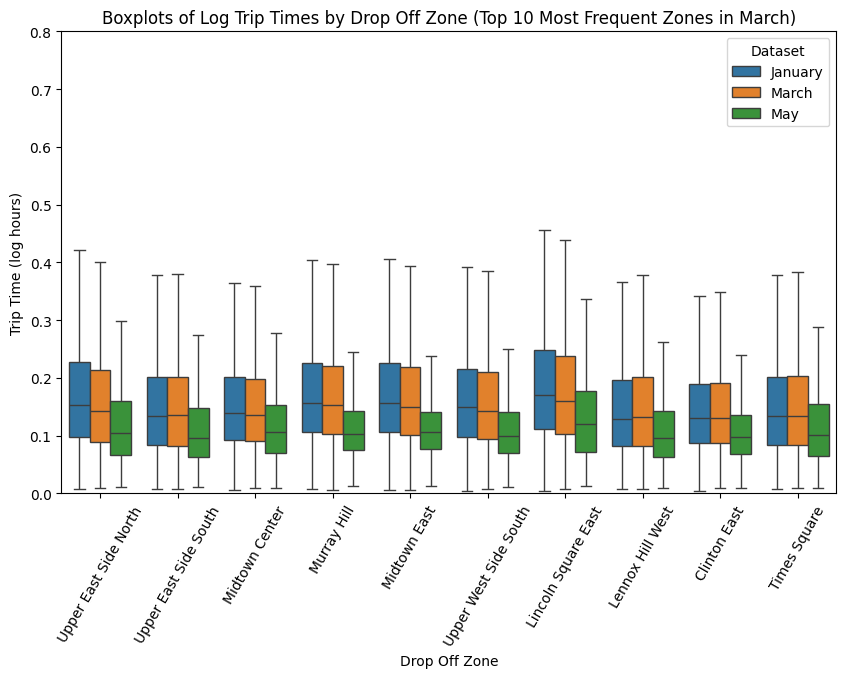

In [100]:
# Log trip times by drop off zone
ax = hue_plots(
    custom_boxplot, # underlying custom plot function
    [
        jan_data[jan_data.do_location_id.isin(top_10_do_zones)][['do_location_id', 'trip_time']]\
            .astype({'do_location_id': int}),
        march_data[march_data.do_location_id.isin(top_10_do_zones)][['do_location_id', 'trip_time']]\
            .astype({'do_location_id': int}),
        may_data[may_data.do_location_id.isin(top_10_do_zones)][['do_location_id', 'trip_time']]\
            .astype({'do_location_id': int})
    ], # datasets, sliced on 10 most common drop off zones for clarity
    plot_kwargs = dict( # kwargs to pass to underlying plot
        x = 'do_location_id', # categorical variable to split on
        y = 'trip_time', # target
        orient = 'v', # orientation
        log1p_y = True, # apply log transformation
        xticklabels = [ # fix x-tick labels for better clarity
            'Upper East Side North', 'Upper East Side South', 'Midtown Center',
            'Murray Hill', 'Midtown East', 'Upper West Side South',
            'Lincoln Square East', 'Lennox Hill West', 'Clinton East', 'Times Square'
        ],
        tick_rotation = 60,
        xlabel = 'Drop Off Zone',
        ylabel = 'Trip Time (log hours)', # clean up y-label
        ylim = [0, 0.75], # y-axis limits to fit previously discovered limits for log trip time,
        figsize = (12, 6) # control figsize
    ),
    labels = ['January', 'March', 'May'], # labels for legend
    title = 'Boxplots of Log Trip Times by Drop Off Zone (Top 10 Most Frequent Zones in March)', # plot title
);

# Preparation for Modeling

Transformations for modeling:
- Prune data so that log1p(trip_time) $\leq$ 0.75 and 1 $\leq$ log1p(fare_amount) $\leq$ 5.
- Only select trip time (target), fare amount, tip amount, tolls amount, payment type, rate code, pick up location, and drop off location as variables based on moderate-high Pearson correlation and Kruskal-Wallis H-statistics. Trip distance and total amount are dropped to remove multicollinearity. Other features are deemed too weak to be useful based on correlation and H-statistics.
- Log-transform trip time and fare amount, then standardize.
- Standardize tip amount and tolls amount.
- One hot encode payment type and rate code, as they only have 5 and 6 categories, respectively.
- Target encode pick up location and drop off location on the log-transformed and standardized trip time, as each feature has over 200 categories.

In [101]:
# Prepare for modeling by selecting features and encoding variables
# Target variable is now named "log_trip_time"
jan_data = feature_select_and_encode_eda(jan_data)
march_data = feature_select_and_encode_eda(march_data)
may_data = feature_select_and_encode_eda(may_data)

In [102]:
# Save processed data to new parquet files for future use in modeling
jan_data.to_parquet('../data/processed_yellow_tripdata_2020-01.parquet', index = False)
march_data.to_parquet('../data/processed_yellow_tripdata_2020-03.parquet', index = False)
may_data.to_parquet('../data/processed_yellow_tripdata_2020-05.parquet', index = False)

# EDA Conclusions (Most Useful Patterns, Data Drift Observations)

The following is a summary of the EDA performed within the notebook.

### Data Cleaning and Outlier Removal

Missing and Univalent Columns were removed:
- Airport fee (completely missing)
- Store and forward flag (nearly univalent and not relevant)
- Improvement surcharge (univalent)

Data was enforced to match NYC rules and laws via the data dictionary:
- Passenger count was clipped to between 1 and 5 to match taxi laws
- Rate code was imputed by taxi zone rules and enforced for consistency
- Congestion surcharge was enforced to \\$0, \\$0.75, and \\$2.50, following rate rules for different groups

Physical plausability was enforced to remove unrealistic data points:
- Trip times were required to be positive and less than or equal to 6 hours
- Trip distance was restricted to between 0.25 miles (5 city street blocks) and 44 miles for trips within the city to ensure only real trips were included
- All monetary columns were forced to be positive
- Fare amounts were capped at \\$1,000
- Toll amounts were capped at \\$50
- Tip amounts were capped at \\$120

### Important Features and Interpretation

Continuous Features (identified by Pearson correlation):
- Fare amount showed high correlation with trip time ($r = 0.82$) and exhibited a potential exponential relationship with trip time. As fares increased, trip time increased which intuitively makes sense as longer trips incur a higher fare since the fare is charged for every minute passed during the trip.
- Tip amount showed moderate correlation with trip time ($r = 0.44$). Most passengers tip a percentage of their fare amount, so tip amounts tend to rise as trip time increases.
- Tolls amount also showed moderate correlation with trip time ($r = 0.41$). Trips which passed outside of the city tended to be longer, so longer trips had a higher rate of toll charges.

Categorical Features (identified by Kruskal-Wallis H-statistic):
- Pick up location and drop off location were useful features for predicting trip time. There were too many zones to inspect each individual zone, but certain zones such as the Upper West Side showed significantly higher trip times from the average trip time.
- Payment type was a useful predictor, particularly the use of Flex pay. Flex payment is used for e-hailing, and all of the costs for the trip are up front. This makes it less likely for passengers using Flex payment to end their trip early, as they have already prepaid. In addition, Flex payment trips are usually pre-planned, and most users book trips in advance specifically because the trip is longer than what can be covered feasibly using other methods of transportation.
- Rate code was a strong predictor of trip time, as rate codes to airports (JFK and Newark) or outside of the city (Nassau / Westchester and Negotiated) indicate trips that go outside of the NYC limits. These trips were naturally longer than intra-city trips. Even though over 97% of trips used the Standard rate code for within city trips, the remaining 3% of trips using these codes showed significantly increased trip times.

### Data Drift

January vs. March Datasets:
- The largest difference in the datasets is in the volume of taxi rides. January had 6.25 million records to only 2.94 million in March, a 52.96% decrease in taxi rides. This coincides with the increase of quarantine protocols as COVID-19 became officially recognized as a global pandemic.
- A new vendor, Myle Technologies Inc., started business after the January dataset.
- There was a small amount of data drift in the monetary columns detected by Tensorflow Data Validation; however, upon further visual and statistical inspection, the drift was neglible.
- In almost all variables, the January and March datasets showed nearly identical trends and distributions. Despite the assumption that March 2020 was the development of a "new normal" for the taxi industry, it would appear that the data had not shifted significantly from January 2020. Training a model on January data would likely perform well on March data.

March vs. May Datasets:
- There was an enormous drop in volume of taxi rides in the May dataset compared to the March dataset. March had 2.94 million records, while May had 332 thousand records, an 88.7% drop in volume. By May 2020, the pandemic was fully underway, and most people were social distancing and staying at home.
- There was a fairly large amount of data drift between the two datasets. March 2020 was still relatively early in the life-cycle of the pandemic, but by May 2020, the pandemic was fully underway and recognized.
- There was a huge decrease in trips outside of the city (a decrease in out-of-town and airport rate codes), as most people were not traveling due to COVID-19. This also resulted in fewer tolls paid. For similar reasons, common tourist locations such as Times Square and airport locations such as JFK and Newark were much less present in the May dataset. Parts of the city known for their office spaces such as Midtown were much less frequented as people moved to remote work from home. Conversely, city locations near parks such as Central Park were more common during May, as these were some of the few remaining places that people could gather while still obeying the rules for social distancing.
- Flex pay, used in conjuction with e-hail apps, became more popular during May. Passengers were less likely to randomly hail down a taxi and instead planned their trips in advance. Flex pay trips are paid up front, so more trips went to completion, leading to an increase in trip distance since passengers are less likely to end their trip early after having already paid for the trip. Because there was such a drastic decrease in traffic, trip times were lower despite higher trip distance.
- Although the March and May datasets shared similar trends for many variables, in nearly all variables, there was a noticeable distribution difference between the datasets. It would appear that there was a significant drift from March to May, and it may be that March is not the ideal selection for a "new baseline". A model trained on March data should still perform decently on the May data, but based on this EDA, such a model would not be expected to generalize as well as a January to March model.

### Optimization for Modeling

Removing Multicollinearity:
- Total amount, fare amount, and trip distance show high multicollinearity because they contain similar information. Longer trips have higher fares, and the majority of the total charges is comprised of the base fare. Removing total amount and one of fare amount or trip distance eliminates multicollinearity, as the additional columns are redundant. Fare amount was chosen as the only column to maintain.

Feature Selection:
- Pick up location, drop off location, rate code, and payment type for categorical variables
- Fare amount, tip amount, and tolls amount for continuous variables

Reducing Skew via Log Transformations, Further Data Pruning, and Standardization:
- The target, trip time was log + 1 transformed to reduce right skewness. Further investigation suggests pruning the data to fit between 0 and 0.75 log trip time due to less than 0.3% of the March data having log trip times greater than 0.75.
- Fare amount was log + 1 transformed to reduce right skewness, and as a result, is nearly normal. Investigation suggests pruning the data to between 1 and 5 log fares, as less than 0.01% of the March data has log fares greater than 5, with 0% of the data having log fares less than 1.
- Both of these variables, along with tip amount and tolls amount, should be standardized to improve gradient and distance-based learning, such as with Support Vector Machines or Neural networks.

Column Encoding:
- Pick up location and drop off location each contain over 200 categories. These features are not ordinal. Since there are so many categories, it would be a poor choice to one-hot encode these features, as doing so would lead to an explosive increase in dataset dimensionality. Instead, target encoding will be used, which will naturally capture the average trip time for each category for each feature, preventing an increase in dimensionality and giving stronger weight to categories with higher trip times. Note that standardization should not be necessary for the target encoding, as the target encoding should be done after scaling trip time and thus is already scaled.
- Payment type and rate code have 5 and 6 categories respectively. They are not ordinal. Although there might be room to do some clever type of encoding to prevent an increase in dimensionality, one-hot encoding these columns would only add 9 columns total which is a small dimensionality increase, especially given the size of the datasets. As such, these columns will be one-hot encoded and do not need to be standardized, as one-hot columns are naturally scaled.